## 1. What this notebook computes

This notebook computes the **curvature** of the author's metric of the primordial
gravitational field, exactly, with sympy, for a general metric function $a_4(x_4)$.
It

- reads the metric exactly as the author typed it (from the Revision record
  `Revision/gkd_lovelock/results/curvature.json`);
- computes all $8^3 = 512$ **Christoffel symbols** $\Gamma^a{}_{bc}$, finds the 37
  that are not zero, checks them against the record of the Rust program
  `lovelock_gkd`, draws them as heat maps and as functions of $z$, and checks them a
  second, independent way by **finite differences** (a numerical derivative);
- shows that the lines along the time $x_4$ are **geodesics** (free fall) with
  proper time $x_4$;
- computes the **Riemann tensor** $R^a{}_{bcd}$ and its form $R^{ab}{}_{cd}$ with two
  upper indices, finds its 156 non-zero components, checks its symmetries and the
  first Bianchi identity, and compares all 156 with the record;
- computes the **Ricci tensor**, the **Ricci scalar** and the **Einstein tensor**,
  compares them with the record and the lead's checks, and checks the contracted
  Bianchi identity $\nabla_\mu G^\mu{}_\nu = 0$;
- computes the **Kretschmann scalar** $K = R^{ab}{}_{cd} R^{cd}{}_{ab}$, shows that it
  does not depend on $z$ although single components do, and that it is never zero
  for $H > 0$;
- evaluates everything along the **deflating history** $a_4 = A H x_4$ ($A > 0$) and
  checks that minus the time component and the space component of the Einstein
  tensor are exactly the energy density and the pressure that the Revision record
  of the field equations of $a_4$ lists for this history;
- repeats the curvature for a **negative control** in which the extra times inflate
  instead of deflating, and shows what then changes;
- draws 7 figures and prints a PASS line for every check.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 03b (The curvature of the author's metric: Christoffel, Riemann, Ricci,
Einstein, Kretschmann) is the file `Revision/textbook/notebooks/03b_curvature.ipynb` of
the repository Dirac_claude. It computes with sympy, from the metric exactly as the
author typed it and with a general function a4(x4), all 512 Christoffel symbols, the
Riemann tensor, the Ricci tensor, the Ricci scalar, the Einstein tensor and the
Kretschmann scalar; it compares every component with the Revision record of the Rust
program lovelock_gkd (exactly, and numerically at the five test points of the independent
Revision verification), checks the symmetries of the Riemann tensor, the first and the
contracted Bianchi identities, the Christoffel symbols by finite differences, and a
negative control with inflating extra times; and it draws the Christoffel symbols, the
curvature of every coordinate plane, the components and the curvature scalars versus z
and versus the expansion rate, and the Einstein tensor; along the deflating history a4 =
A H x4 it reproduces the source that the Einstein equations require in the Revision
record of the field equations of a4. It needs a computer with Windows 11, macOS or Linux,
an internet connection for the installation, the program Git, and Python 3.12 or newer
(the notebooks were built with Python 3.14.5) with these packages at exactly these
versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab 4.4.10,
nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The notebook
itself imports numpy, sympy, mpmath and matplotlib; the other packages run Jupyter, the
program that shows and runs notebooks. It does not need Rust.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (about 130 MB; the folder then takes about 400
MB of disk space) into the folder Dirac_claude inside your home folder, create a private
Python environment in the folder dirac-book-env inside your home folder (a private
environment is a folder with its own copy of Python and of the packages, so that nothing
else on your computer is changed), activate it (from then on the commands `python` and
`jupyter` typed in this terminal are those of the environment, and the prompt starts with
(dirac-book-env)), and install the packages at the pinned versions (this downloads about
90 MB and takes a few minutes; the environment takes about 400 MB of disk space). If you
have done this step before, for this or for another notebook, skip it and go to Step 4;
to get the newest version of the repository, run `git pull` in the repository folder
after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 03b_curvature.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 1 minute on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 6. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 03b_curvature.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
03b_curvature.ipynb` (in the same folder, without running the cells again) to read the
printed lines and see the figures.

**Step 7. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:

- `Revision/textbook/figures/03b.captions.json`
- `Revision/textbook/figures/03b_1_christoffel_heat_maps.png`
- `Revision/textbook/figures/03b_2_christoffel_versus_z.png`
- `Revision/textbook/figures/03b_3_finite_differences.png`
- `Revision/textbook/figures/03b_4_plane_curvatures.png`
- `Revision/textbook/figures/03b_5_riemann_and_kretschmann_z.png`
- `Revision/textbook/figures/03b_6_scalars_versus_a.png`
- `Revision/textbook/figures/03b_7_einstein_tensor.png`

It changes no other file of the repository; running it headless or saving it in
JupyterLab also rewrites the notebook file itself. It does not use the internet while it
runs. The files it writes are the same files that are stored in the repository (on
another computer a figure may differ in a few bytes, which is harmless). To get the
stored versions back, run this command in the repository folder (it also undoes every
change you made yourself in the folder Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS all seven figure files exist
    ALL 39 CHECKS PASSED (notebook 03b)

and the notebook must show 7 figures below the cells that draw them.

**Step 8. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/03b_curvature.ipynb` inside the folder Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4 (or type `python -m jupyter` instead of `jupyter`).
- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.
- The cells with the Riemann tensor and the negative control run for up to half a minute
  each, and their label shows a star meanwhile: this is normal: sympy simplifies several
  thousand expressions exactly; wait until the label shows a number.

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 03b (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 03b (The curvature of the author's metric: Christoffel, Riemann, Ricci,
# Einstein, Kretschmann) is the file Revision/textbook/notebooks/03b_curvature.ipynb of
# the repository Dirac_claude. It computes with sympy, from the metric exactly as the
# author typed it and with a general function a4(x4), all 512 Christoffel symbols, the
# Riemann tensor, the Ricci tensor, the Ricci scalar, the Einstein tensor and the
# Kretschmann scalar; it compares every component with the Revision record of the Rust
# program lovelock_gkd (exactly, and numerically at the five test points of the
# independent Revision verification), checks the symmetries of the Riemann tensor, the
# first and the contracted Bianchi identities, the Christoffel symbols by finite
# differences, and a negative control with inflating extra times; and it draws the
# Christoffel symbols, the curvature of every coordinate plane, the components and the
# curvature scalars versus z and versus the expansion rate, and the Einstein tensor;
# along the deflating history a4 = A H x4 it reproduces the source that the Einstein
# equations require in the Revision record of the field equations of a4. It needs a
# computer with Windows 11, macOS or Linux, an internet connection for the installation,
# the program Git, and Python 3.12 or newer (the notebooks were built with Python 3.14.5)
# with these packages at exactly these versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0,
# matplotlib 3.11.0, jupyterlab 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0
# and nbconvert 7.16.6. The notebook itself imports numpy, sympy, mpmath and matplotlib;
# the other packages run Jupyter, the program that shows and runs notebooks. It does not
# need Rust.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (about 130 MB; the folder then takes about
# 400 MB of disk space) into the folder Dirac_claude inside your home folder, create a
# private Python environment in the folder dirac-book-env inside your home folder (a
# private environment is a folder with its own copy of Python and of the packages, so
# that nothing else on your computer is changed), activate it (from then on the commands
# python and jupyter typed in this terminal are those of the environment, and the prompt
# starts with (dirac-book-env)), and install the packages at the pinned versions (this
# downloads about 90 MB and takes a few minutes; the environment takes about 400 MB of
# disk space). If you have done this step before, for this or for another notebook, skip
# it and go to Step 4; to get the newest version of the repository, run git pull in the
# repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 03b_curvature.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 1 minute
# on a typical laptop. Scroll to the end and compare the last printed lines with the
# lines in the step "What the notebook writes and what you must see" below. To keep the
# results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose the
# menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 6. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 03b_curvature.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 03b_curvature.ipynb (in the same folder, without running the cells again) to read the
# printed lines and see the figures.
#
# STEP 7. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
#
# - Revision/textbook/figures/03b.captions.json
# - Revision/textbook/figures/03b_1_christoffel_heat_maps.png
# - Revision/textbook/figures/03b_2_christoffel_versus_z.png
# - Revision/textbook/figures/03b_3_finite_differences.png
# - Revision/textbook/figures/03b_4_plane_curvatures.png
# - Revision/textbook/figures/03b_5_riemann_and_kretschmann_z.png
# - Revision/textbook/figures/03b_6_scalars_versus_a.png
# - Revision/textbook/figures/03b_7_einstein_tensor.png
#
# It changes no other file of the repository; running it headless or saving it in
# JupyterLab also rewrites the notebook file itself. It does not use the internet while
# it runs. The files it writes are the same files that are stored in the repository (on
# another computer a figure may differ in a few bytes, which is harmless). To get the
# stored versions back, run this command in the repository folder (it also undoes every
# change you made yourself in the folder Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS all seven figure files exist
#     ALL 39 CHECKS PASSED (notebook 03b)
#
# and the notebook must show 7 figures below the cells that draw them.
#
# STEP 8. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/03b_curvature.ipynb inside the folder Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4 (or type python -m jupyter instead of jupyter).
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
# - The cells with the Riemann tensor and the negative control run for up to half a
#   minute each, and their label shows a star meanwhile: this is normal: sympy simplifies
#   several thousand expressions exactly; wait until the label shows a number.
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell

NOTEBOOK_ID = "03b"  # this notebook: chapter 03, example b


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 03b complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Metric** $g_{\mu\nu}$, **inverse metric** $g^{\mu\nu}$ (the inverse matrix:
  $\sum_\lambda g^{\mu\lambda} g_{\lambda\nu} = \delta^\mu{}_\nu$, which is $1$ when
  $\mu = \nu$ and $0$ otherwise). For a diagonal metric $g^{\mu\mu} = 1/g_{\mu\mu}$.
- **Index notation**: $a, b, c, \dots$ each run over the eight coordinates
  $x_1, \dots, x_8$; an upper and a lower index are positions in a table of numbers;
  $\partial_c$ means the partial derivative $\partial/\partial x_c$.
- **Christoffel symbols** $\Gamma^a{}_{bc} = \tfrac12 \sum_d g^{ad}(\partial_b g_{dc}
  + \partial_c g_{db} - \partial_d g_{bc})$: the correction terms that make
  derivatives of vectors independent of the coordinates. They are symmetric in $b$
  and $c$.
- **Geodesic**: a curve $x^a(\tau)$ with $d^2x^a/d\tau^2 + \sum_{b,c}
  \Gamma^a{}_{bc}\,(dx^b/d\tau)(dx^c/d\tau) = 0$, the path of free fall, the
  straightest possible curve.
- **Riemann tensor** $R^a{}_{bcd} = \partial_c \Gamma^a{}_{bd} - \partial_d
  \Gamma^a{}_{bc} + \sum_e (\Gamma^a{}_{ce}\Gamma^e{}_{bd} - \Gamma^a{}_{de}
  \Gamma^e{}_{bc})$ (the convention of the textbook of Misner, Thorne and Wheeler,
  MTW, used by every Revision record): it measures how much a vector turns when it
  is carried around a small closed loop. It is zero everywhere exactly when the space
  is flat.
- $R^{ab}{}_{cd} = \sum_e g^{be} R^a{}_{ecd}$: the same tensor with the second index
  raised. For the coordinate plane of $x_a$ and $x_b$, $R^{ab}{}_{ab}$ (no sum) is the
  **curvature of that plane** (the sectional curvature): positive like a sphere,
  negative like a saddle.
- **Ricci tensor** $R^a{}_b = \sum_c R^{ac}{}_{bc}$, **Ricci scalar**
  $R = \sum_a R^a{}_a$, **Einstein tensor** $G^a{}_b = R^a{}_b - \tfrac12
  \delta^a{}_b R$: the averages of the curvature that enter Einstein's field
  equations.
- **Kretschmann scalar** $K = \sum_{a,b,c,d} R^{ab}{}_{cd} R^{cd}{}_{ab}$: one number
  per point, the same in every coordinate system (an **invariant**).
- **Einstein's field equations** $G^\mu{}_\nu + \Lambda\,\delta^\mu{}_\nu =
  \kappa\, T^\mu{}_\nu$: the Einstein tensor plus a constant $\Lambda$ (the
  **cosmological constant**) times $\delta^\mu{}_\nu$ equals a positive constant
  $\kappa$ times the **energy-momentum tensor** $T^\mu{}_\nu$ of the matter. For the
  sources of this book its diagonal is $T = \mathrm{diag}(p_3, p_3, p_3, -\rho, p_t,
  p_t, p_t, p_8)$: the **energy density** $\rho$ (energy per unit volume) and the
  **pressures** $p_3$ of 3-space, $p_t$ of the extra times and $p_8$ of the hidden
  direction. A later chapter derives these equations; this notebook only reads
  them in a Revision record.
- **Bianchi identities**: $R^a{}_{bcd} + R^a{}_{cdb} + R^a{}_{dbc} = 0$ (first) and
  $\nabla_\mu G^\mu{}_\nu = 0$ (contracted): identities that every metric satisfies;
  checking them checks the computation.
- **Finite difference**: the numerical derivative $f'(x) \approx (f(x+h) -
  f(x-h))/(2h)$; its error shrinks like $h^2$.
- `a4p`, `a4pp`, `a4v`: the names the notebook prints for $a_4'$, $a_4''$ and the
  value of $a_4$; `z` stands for $6 H x_8$.

## 4. The physical and mathematical situation

The metric of the author is diagonal,

$$g = \mathrm{diag}\bigl(e^{2a_4}\sin^{1/3}z\ (\times 3),\ -1,\
-e^{-2a_4}\sin^{1/3}z\ (\times 3),\ \cot^2 z\bigr), \qquad z = 6 H x_8,$$

in the order $x_1, \dots, x_8$, with the constant $H > 0$ and the metric function
$a_4(x_4)$. It depends on two coordinates only, $x_4$ (through $a_4$) and $x_8$
(through $z$). Every derivative along $x_1, x_2, x_3, x_5, x_6, x_7$ is therefore
zero, which is why most of the $512$ Christoffel symbols and most of the $4096$
Riemann components vanish.

Curvature is computed in three steps, each from the previous one: the Christoffel
symbols need the first derivatives of the metric; the Riemann tensor needs the
first derivatives of the Christoffel symbols and their products (so the second
derivatives of the metric, and $a_4''$ appears); the Ricci tensor, the Ricci scalar
and the Einstein tensor are sums of Riemann components. The Revision record
computed all of this with an exact Rust program (`lovelock_gkd`); an independent
sympy program checked every component, and the lead's own sympy code recomputed the
Einstein tensor. This notebook does it once more, in small steps, and compares every
single component.

Nothing here involves the matter fields yet: these are exact properties of the given
metric. The field equations, which connect the Einstein tensor to the energy and the
pressures of the fields, are the subject of a later chapter. For the plots the
notebook uses $H = 1$ and the deflating history $a_4 = A H x_4$ of the Revision
Kohn-Sham work (so $a_4' = A H$ and $a_4'' = 0$, with $A = 1$ the canonical value):
a PRESCRIBED BACKGROUND, assumed here and not obtained by solving the field
equations.

## 5. The metric, read from the record

The next cell imports the packages, reads the record, and makes the symbols: the
eight coordinates, $H > 0$, the unknown function $a_4(x_4)$, and the printing names
`a4p`, `a4pp`, `a4v` and `z`. The function `plain` rewrites an expression with these
printing names; the function `symbolic` does the same but keeps $x_8$ (the record
writes its components with $x_8$).

In [2]:
import itertools  # loops over all index combinations

import mpmath  # numbers with many digits
import numpy as np  # arrays of numbers
import sympy as sp  # exact algebra with symbols
from sympy.parsing.sympy_parser import (implicit_multiplication, parse_expr,
                                        standard_transformations)

CURVATURE_RECORD = "Revision/gkd_lovelock/results/curvature.json"
record = json.loads(repository_file(CURVATURE_RECORD).read_text(encoding="utf-8"))
x1, x2, x3, x4, x5, x6, x7, x8 = sp.symbols("x1:9", real=True)
X = [x1, x2, x3, x4, x5, x6, x7, x8]  # the coordinates, counted 0 to 7 in Python
NAMES = ["x1", "x2", "x3", "x4", "x5", "x6", "x7", "x8"]
H = sp.symbols("H", positive=True)  # the constant of the author
a4 = sp.Function("a4")(x4)  # the metric function, unknown
a4p, a4pp, a4v = sp.symbols("a4p a4pp a4v", real=True)  # a4 prime, a4 two primes, a4
z = sp.symbols("z", positive=True)  # z = 6 H x8, for printing


def symbolic(expression):
    """Write the derivatives of a4 as a4p and a4pp and the value a4(x4) as a4v."""
    expression = expression.subs(sp.Derivative(a4, (x4, 2)), a4pp)  # second first
    return expression.subs(sp.Derivative(a4, x4), a4p).subs(a4, a4v)


def plain(expression):
    """As symbolic, and 6 H x8 written as z."""
    return symbolic(expression).subs(x8, z / (6 * H))


say("Record read; symbols x1 ... x8, H, a4(x4), a4p, a4pp, a4v and z defined.")

Record read; symbols x1 ... x8, H, a4(x4), a4p, a4pp, a4v and z defined.


The next cell turns the author's text of the metric into a sympy matrix, with the
same translation rules as Notebook 03a (Mathematica's `exp^` becomes `E^`, square
brackets of functions become round brackets, curly brackets of lists become square
brackets, `^` becomes `**`, and a blank between factors means times), and prints
the diagonal.

In [3]:
text = record["metricAsGiven"]  # the metric exactly as the author typed it
text = text.replace("exp^", "E^").replace("a4[x4]", "a4")
text = text.replace("Sin[6 H x8]", "sin(6 H x8)").replace("Cot[6 H x8]", "cot(6 H x8)")
text = text.replace("{", "[").replace("}", "]").replace("^", "**")
metric_names = {"E": sp.E, "a4": a4, "H": H, "x8": x8, "sin": sp.sin, "cot": sp.cot}
g = sp.Matrix(parse_expr(text, local_dict=metric_names, transformations=(
    standard_transformations + (implicit_multiplication,))))
for k in range(8):
    say(f"  g[{NAMES[k]}, {NAMES[k]}] = {plain(g[k, k])}")
check(all(g[i, j] == 0 for i in range(8) for j in range(8) if i != j),
      "the metric read from the text of the author is diagonal")

  g[x1, x1] = exp(2*a4v)*sin(z)**(1/3)
  g[x2, x2] = exp(2*a4v)*sin(z)**(1/3)
  g[x3, x3] = exp(2*a4v)*sin(z)**(1/3)
  g[x4, x4] = -1
  g[x5, x5] = -exp(-2*a4v)*sin(z)**(1/3)
  g[x6, x6] = -exp(-2*a4v)*sin(z)**(1/3)
  g[x7, x7] = -exp(-2*a4v)*sin(z)**(1/3)
  g[x8, x8] = cot(z)**2
PASS the metric read from the text of the author is diagonal


The record writes its components in Mathematica notation, for example
`Derivative[1][a4][x4]*E^(2*a4[x4])*Sin[6*H*x8]^(1/3)`. The next cell defines the
function `from_mathematica` that translates such a text into sympy:
`Derivative[1][a4][x4]` ($a_4'$) becomes `a4p`, `Derivative[2][a4][x4]` becomes
`a4pp`, `a4[x4]` becomes `a4v`, the sine and the cotangent get round brackets, and
`^` becomes `**`. If any square bracket is left, the translation is incomplete and
the function stops with an error, so a silent mistranslation is impossible.

The cell also defines three helpers. `tidy(expression)` simplifies an expression:
it writes $6Hx_8$ as $z$, simplifies it once as it is and once after writing
$\sin 2z$ as $2\sin z\cos z$ (`expand_trig`), and keeps the shorter of the two
results (sympy sometimes reaches the simplest form only one way: it writes, for
example, $-6H/(\sin z\cos z)$ as $-12H/\sin(2z)$, the same number because
$\sin 2z = 2\sin z\cos z$, and a sum such as $6H\cot z - 12H/\sin 2z + 6H\tan z$ is
recognised as $0$ only after the rewriting). `vanishes(expression)` is true when
`tidy` gives $0$, and `same(mine, theirs)` is true when the difference of our
expression and the record's vanishes.

In [4]:
record_names = {"a4p": a4p, "a4pp": a4pp, "a4v": a4v, "H": H, "x8": x8, "E": sp.E,
                "sin": sp.sin, "cot": sp.cot}


def from_mathematica(entry_text):
    """A component of the record (Mathematica notation) as a sympy expression."""
    t = entry_text.replace("Derivative[1][a4][x4]", "a4p")
    t = t.replace("Derivative[2][a4][x4]", "a4pp").replace("a4[x4]", "a4v")
    t = t.replace("Sin[6*H*x8]", "sin(6*H*x8)").replace("Cot[6*H*x8]", "cot(6*H*x8)")
    t = t.replace("^", "**")
    if "[" in t or "]" in t:
        raise ValueError(f"cannot translate {entry_text}")
    return parse_expr(t, local_dict=record_names)


def tidy(expression):
    """Simplify an expression.  It writes 6 H x8 as z (so that 12 H x8 becomes 2z),
    simplifies it twice, once as it is and once after writing sin(2z) as
    2 sin(z) cos(z) (expand_trig), keeps the shorter result (count_ops counts the
    operations), and writes z as 6 H x8 again."""
    expression = sp.sympify(expression).subs(x8, z / (6 * H))
    first = sp.simplify(expression)
    second = sp.simplify(sp.expand_trig(expression))
    best = second if sp.count_ops(second) < sp.count_ops(first) else first
    return best.subs(z, 6 * H * x8)


def vanishes(expression):
    """True when the expression simplifies to zero."""
    return tidy(expression) == 0


def same(mine, theirs):
    """True when mine (with the function a4) equals theirs (record symbols)."""
    return vanishes(symbolic(mine) - theirs)


example = record["christoffelNonzero_b_le_c"][6]["value"]
say(f"example of a record entry: {example}")
say(f"translated: {from_mathematica(example)}")

example of a record entry: Derivative[1][a4][x4]*E^(2*a4[x4])*Sin[6*H*x8]^(1/3)
translated: a4p*exp(2*a4v)*sin(6*H*x8)**(1/3)


## 6. The Christoffel symbols

The Christoffel symbols of the metric are

$$\Gamma^a{}_{bc} = \tfrac12 \sum_{d=1}^{8} g^{ad}\bigl(\partial_b g_{dc} +
\partial_c g_{db} - \partial_d g_{bc}\bigr).$$

The next cell defines the function `christoffel(metric, coordinates)`, which applies
this formula literally to every one of the $8 \times 8 \times 8 = 512$ index
combinations (it does not use the symmetry in $b$ and $c$, so that the symmetry can
be checked afterwards), simplifies each result, and returns the table
`Gamma[a][b][c]`. Then it computes the symbols of the author's metric and counts
the non-zero ones.

In [5]:
def christoffel(metric, coordinates):
    """All Christoffel symbols Gamma[a][b][c] of a metric, by the formula above."""
    n = len(coordinates)
    inverse = metric.inv()  # the inverse metric g^(ad)
    d_metric = [metric.diff(c) for c in coordinates]  # d_metric[c][i, j] = d_c g_ij
    table = [[[0] * n for _ in range(n)] for _ in range(n)]
    for a, b, c in itertools.product(range(n), repeat=3):
        value = sum(inverse[a, d] * (d_metric[b][d, c] + d_metric[c][d, b]
                                     - d_metric[d][b, c]) for d in range(n)) / 2
        table[a][b][c] = tidy(value)
    return table


Gamma = christoffel(g, X)
nonzero = [(a, b, c) for a, b, c in itertools.product(range(8), repeat=3)
           if Gamma[a][b][c] != 0]
upper_half = [(a, b, c) for a, b, c in nonzero if b <= c]
report("non-zero Christoffel symbols (all orders of b, c)", len(nonzero))
report("non-zero Christoffel symbols with b <= c", len(upper_half))
check(all(Gamma[a][b][c] == Gamma[a][c][b]
          for a, b, c in itertools.product(range(8), repeat=3)),
      "the Christoffel symbols are symmetric in their two lower indices")

RESULT non-zero Christoffel symbols (all orders of b, c) = 37
RESULT non-zero Christoffel symbols with b <= c = 25
PASS the Christoffel symbols are symmetric in their two lower indices


The next cell prints the 25 non-zero symbols with $b \le c$ (the others follow by the
symmetry) and compares them with the list `christoffelNonzero_b_le_c` of the record:
first that the two lists name the same 25 index combinations, then that each value
agrees exactly. In the record the keys `a`, `b`, `c` are the indices of
$\Gamma^a{}_{bc}$. sympy chooses its own way of writing some symbols: $H\cot z$
appears as `H/tan(z)`, $-He^{2a_4}\sin^{1/3}z\,\tan z$ as
`-H*exp(2*a4v)*sin(z)**(4/3)/cos(z)` (because $\sin^{1/3}z\,\tan z =
\sin^{4/3}z/\cos z$), and $\Gamma^{x_8}{}_{x_8x_8} = -6H/(\sin z\cos z)$ as
`-12*H/sin(2*z)`.

In [6]:
for a, b, c in upper_half:
    say(f"  Gamma^{NAMES[a]}_({NAMES[b]} {NAMES[c]}) = {plain(Gamma[a][b][c])}")
record_gamma = {(NAMES.index(e["a"]), NAMES.index(e["b"]), NAMES.index(e["c"])):
                from_mathematica(e["value"])
                for e in record["christoffelNonzero_b_le_c"]}
check(sorted(record_gamma) == upper_half and len(upper_half) == 25,
      "the same 25 non-zero Christoffel symbols as the record")
check(all(same(Gamma[a][b][c], value) for (a, b, c), value in record_gamma.items()),
      "every Christoffel symbol equals the record exactly",
      record=f"{CURVATURE_RECORD}, christoffelNonzero_b_le_c (and "
             "python-lovelock-report.json, check rust_christoffels_agree)")

  Gamma^x1_(x1 x4) = a4p
  Gamma^x1_(x1 x8) = H/tan(z)
  Gamma^x2_(x2 x4) = a4p
  Gamma^x2_(x2 x8) = H/tan(z)
  Gamma^x3_(x3 x4) = a4p
  Gamma^x3_(x3 x8) = H/tan(z)
  Gamma^x4_(x1 x1) = a4p*exp(2*a4v)*sin(z)**(1/3)
  Gamma^x4_(x2 x2) = a4p*exp(2*a4v)*sin(z)**(1/3)
  Gamma^x4_(x3 x3) = a4p*exp(2*a4v)*sin(z)**(1/3)
  Gamma^x4_(x5 x5) = a4p*exp(-2*a4v)*sin(z)**(1/3)
  Gamma^x4_(x6 x6) = a4p*exp(-2*a4v)*sin(z)**(1/3)
  Gamma^x4_(x7 x7) = a4p*exp(-2*a4v)*sin(z)**(1/3)
  Gamma^x5_(x4 x5) = -a4p
  Gamma^x5_(x5 x8) = H/tan(z)
  Gamma^x6_(x4 x6) = -a4p
  Gamma^x6_(x6 x8) = H/tan(z)
  Gamma^x7_(x4 x7) = -a4p
  Gamma^x7_(x7 x8) = H/tan(z)
  Gamma^x8_(x1 x1) = -H*exp(2*a4v)*sin(z)**(4/3)/cos(z)
  Gamma^x8_(x2 x2) = -H*exp(2*a4v)*sin(z)**(4/3)/cos(z)
  Gamma^x8_(x3 x3) = -H*exp(2*a4v)*sin(z)**(4/3)/cos(z)
  Gamma^x8_(x5 x5) = H*exp(-2*a4v)*sin(z)**(4/3)/cos(z)
  Gamma^x8_(x6 x6) = H*exp(-2*a4v)*sin(z)**(4/3)/cos(z)
  Gamma^x8_(x7 x7) = H*exp(-2*a4v)*sin(z)**(4/3)/cos(z)
  Gamma^x8_(x8 x8) = -12*H/s

The next cell sets the colours of the figures (a palette whose colours can also be
told apart with a colour-vision deficiency; the figures also use line styles and
labels) and turns every Christoffel symbol into a fast numerical function of $z$,
$a_4$, $a_4'$ and $H$ (`sp.lambdify`). It then draws the eight $8 \times 8$ tables
$\Gamma^{x_k}{}_{bc}$ at the point $z = \pi/4$ with $H = 1$, $a_4 = 0.5$, $a_4' = 1$
as heat maps. The colour scale is **symmetric-logarithmic**: above $0.1$ in size,
equal steps of colour stand for equal factors of size (below $0.1$ the scale is
ordinary), so that small and large symbols are both visible; grey is zero, red
positive, blue negative.

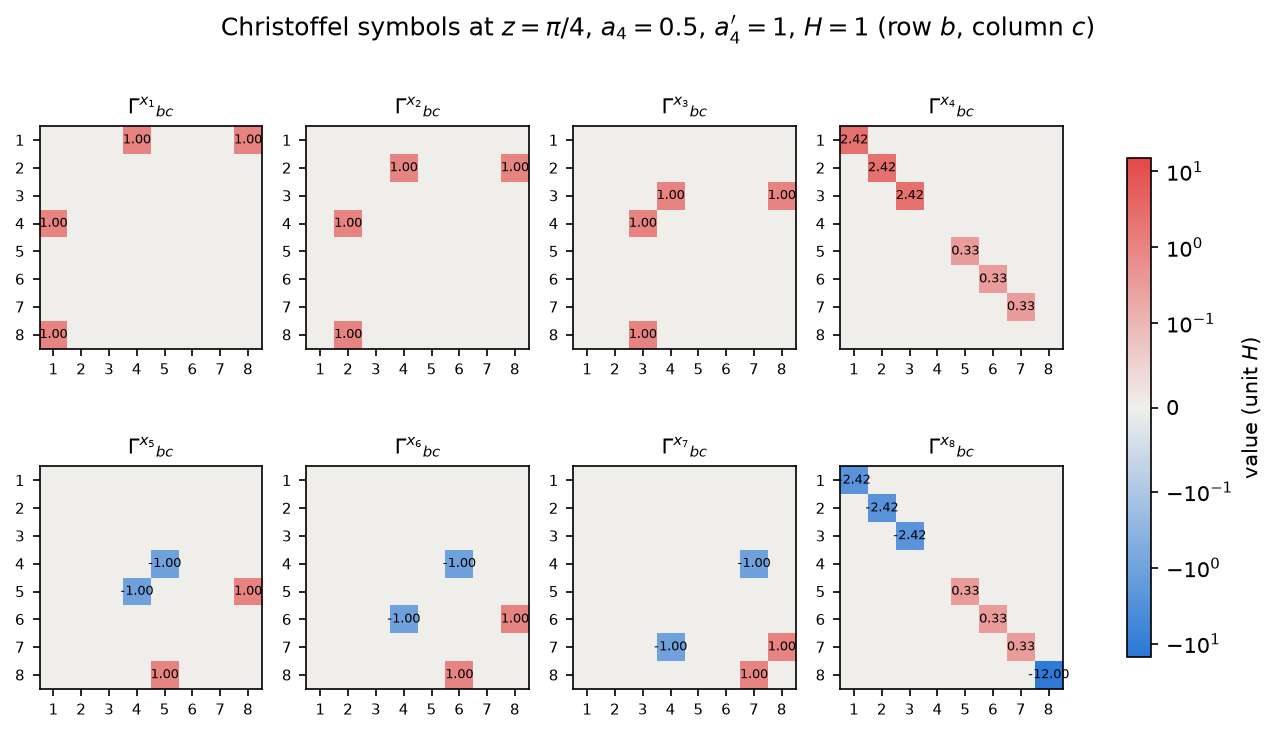

Figure 03b.1 saved as Revision/textbook/figures/03b_1_christoffel_heat_maps.png
PASS the tables are symmetric in b, c; every non-zero symbol has an index x4 or x8


In [7]:
from matplotlib.colors import LinearSegmentedColormap, SymLogNorm

BLUE, ORANGE, AQUA, YELLOW = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
MAGENTA, GREEN, VIOLET, RED = "#e87ba4", "#008300", "#4a3aa7", "#e34948"
DIVERGING = LinearSegmentedColormap.from_list("blue_grey_red", [BLUE, "#f0efec", RED])
LABELS = [f"$x_{k}$" for k in range(1, 9)]
ARGS = (z, a4v, a4p, H)  # the arguments of the numerical functions


def numeric(expression):
    """A numerical function f(z, a4v, a4p, H) of an expression."""
    return sp.lambdify(ARGS, plain(expression), "numpy")


gamma_functions = {(a, b, c): numeric(Gamma[a][b][c]) for a, b, c in nonzero}
POINT = (np.pi / 4, 0.5, 1.0, 1.0)  # z, a4, a4p, H: the canonical slice a4 = 0.5
tables = np.zeros((8, 8, 8))
for (a, b, c), f in gamma_functions.items():
    tables[a, b, c] = f(*POINT)
fig, axes = plt.subplots(2, 4, figsize=(11.0, 5.4))
norm = SymLogNorm(linthresh=0.1, vmin=-15.0, vmax=15.0, base=10)
for a, ax in enumerate(axes.flat):
    image = ax.imshow(tables[a], cmap=DIVERGING, norm=norm)
    for b, c in itertools.product(range(8), repeat=2):
        if tables[a, b, c] != 0:
            ax.text(c, b, f"{tables[a, b, c]:.2f}", ha="center", va="center",
                    fontsize=6.0)
    ax.set_title(f"$\\Gamma^{{x_{a + 1}}}{{}}_{{bc}}$", fontsize=10)
    ax.set_xticks(range(8), [str(k) for k in range(1, 9)], fontsize=7)
    ax.set_yticks(range(8), [str(k) for k in range(1, 9)], fontsize=7)
    ax.grid(False)
fig.colorbar(image, ax=axes, shrink=0.8, label="value (unit $H$)")
fig.suptitle("Christoffel symbols at $z = \\pi/4$, $a_4 = 0.5$, "
             "$a_4^{\\prime} = 1$, $H = 1$ (row $b$, column $c$)")
save_figure(fig, "christoffel_heat_maps",
            "The 512 Christoffel symbols $\\Gamma^{a}{}_{bc}$ of the author's metric "
            "at the point $z = \\pi/4$ on the slice $a_4 = 0.5$ of the history "
            "$a_4 = x_4$ ($a_4^{\\prime} = 1$, $H = 1$), as eight heat maps, one "
            "for each upper index $a = x_1, \\dots, x_8$; in each map the row is $b$ "
            "and the column is $c$ (numbers $1$ to $8$ for $x_1$ to $x_8$), the "
            "colour is the value on a symmetric logarithmic scale (grey zero, red "
            "positive, blue negative) and every non-zero value is printed. Only 37 "
            "of the 512 squares are coloured, each map is symmetric about its "
            "diagonal, and every non-zero symbol has at least one index equal to "
            "$x_4$ or $x_8$, the two coordinates on which the metric depends.")
check(np.allclose(tables, tables.transpose(0, 2, 1))
      and all(3 in key or 7 in key for key in nonzero),
      "the tables are symmetric in b, c; every non-zero symbol has an index x4 or x8")

The symbols with an index $x_8$ depend on $z$. The next cell draws the size of five
typical symbols across the patch on a logarithmic axis (for $a_4 = 0.5$,
$a_4' = 1$, $H = 1$): $\Gamma^{x_1}{}_{x_1 x_8} = H\cot z$ and
$\Gamma^{x_8}{}_{x_8 x_8}$ grow without bound at the tip $z \to 0$;
$\Gamma^{x_8}{}_{x_1 x_1}$, $\Gamma^{x_8}{}_{x_8 x_8}$ and
$\Gamma^{x_8}{}_{x_5 x_5}$ grow without bound at the patch end $z \to \pi/2$;
$\Gamma^{x_1}{}_{x_1 x_4} = a_4'$ does not depend on $z$. Large Christoffel symbols
are a property of the coordinates; whether the geometry itself is extreme is decided
by invariants such as the Kretschmann scalar of section 12.

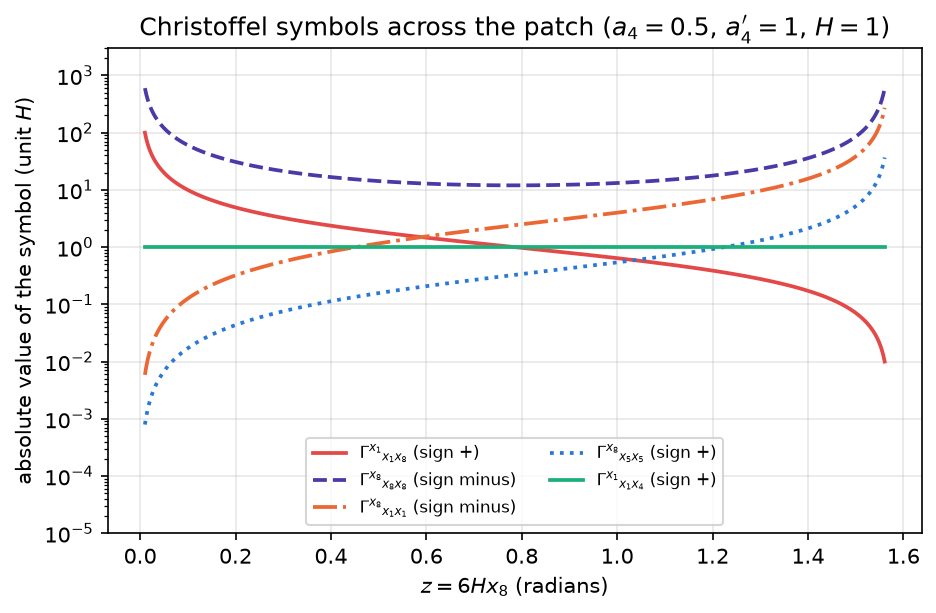

Figure 03b.2 saved as Revision/textbook/figures/03b_2_christoffel_versus_z.png
PASS Gamma^x1_(x1 x8) = H cot z equals 1 at z = pi/4, H = 1


In [8]:
z_line = np.linspace(0.01, np.pi / 2 - 0.01, 500)
chosen = [((0, 0, 7), RED, "-", "$\\Gamma^{x_1}{}_{x_1 x_8}$"),
          ((7, 7, 7), VIOLET, "--", "$\\Gamma^{x_8}{}_{x_8 x_8}$"),
          ((7, 0, 0), ORANGE, "-.", "$\\Gamma^{x_8}{}_{x_1 x_1}$"),
          ((7, 4, 4), BLUE, ":", "$\\Gamma^{x_8}{}_{x_5 x_5}$"),
          ((0, 0, 3), AQUA, "-", "$\\Gamma^{x_1}{}_{x_1 x_4}$")]
fig, ax = plt.subplots()
for index, colour, style, label in chosen:
    values = np.broadcast_to(gamma_functions[index](z_line, 0.5, 1.0, 1.0),
                             z_line.shape)
    sign = "+" if values[len(values) // 2] > 0 else "minus"
    ax.plot(z_line, np.abs(values), color=colour, ls=style, lw=1.8,
            label=f"{label} (sign {sign})")
ax.set_yscale("log")
ax.set_xlabel("$z = 6 H x_8$ (radians)")
ax.set_ylabel("absolute value of the symbol (unit $H$)")
ax.set_title("Christoffel symbols across the patch "
             "($a_4 = 0.5$, $a_4^{\\prime} = 1$, $H = 1$)")
ax.set_ylim(1e-5, 3e3)  # room below the curves for the legend
ax.legend(fontsize=8, loc="lower center", ncol=2)
save_figure(fig, "christoffel_versus_z",
            "The absolute values of five Christoffel symbols of the author's metric "
            "across the patch $0 < z < \\pi/2$, for $a_4 = 0.5$, $a_4^{\\prime} = 1$, "
            "$H = 1$, on a logarithmic vertical axis; horizontal axis "
            "$z = 6Hx_8$ in radians, vertical axis the absolute value in units of "
            "$H$; the legend gives each sign. $\\Gamma^{x_1}{}_{x_1x_8} = H\\cot z$ "
            "falls from the tip to the patch end, $\\Gamma^{x_8}{}_{x_8x_8}$ is "
            "large at both ends, $\\Gamma^{x_8}{}_{x_1x_1}$ and "
            "$\\Gamma^{x_8}{}_{x_5x_5}$ grow towards the patch end, and "
            "$\\Gamma^{x_1}{}_{x_1x_4} = a_4^{\\prime} = 1$ is the same everywhere.")
check(abs(gamma_functions[(0, 0, 7)](np.pi / 4, 0.5, 1.0, 1.0) - 1.0) < 1e-14,
      "Gamma^x1_(x1 x8) = H cot z equals 1 at z = pi/4, H = 1")

## 7. A second, independent check: finite differences

The exact symbols can be checked without any algebra. Take a concrete function
$a_4(x_4) = 0.17 + 0.61\,x_4 - 0.185\,x_4^2$ (so that at $x_4 = 0$:
$a_4 = 0.17$, $a_4' = 0.61$, $a_4'' = -0.37$), $H = 0.23$ and the point
$x_8 = 0.41$: the test point at which the Rust program checked its Lovelock tensors
by brute force (record `lovelock-report.json`, check `k1_brute_force_numeric`).
The next cell first confirms these numbers in the record. Then it computes the
metric as a plain table of numbers at points $x \pm h\,e_c$ (one coordinate moved by
$\pm h$), the derivative of the metric by the central difference
$\partial_c g \approx (g(x + h e_c) - g(x - h e_c))/(2h)$, and from it all 512
Christoffel symbols with the same formula; it compares them with the exact symbols
for eight step sizes $h$ from $10^{-1}$ to $10^{-8}$.

In [9]:
RUST_REPORT = "Revision/gkd_lovelock/results/lovelock-report.json"
rust_report = json.loads(repository_file(RUST_REPORT).read_text(encoding="utf-8"))
prime = chr(39)  # the apostrophe (character number 39): the record writes a4 prime so
point_text = (f"H = 0.23, a4 = 0.17, a4{prime} = 0.61, a4{prime}{prime} = -0.37, "
              "x8 = 0.41")  # the test point as the record writes it
check(point_text in rust_report["checks"]["k1_brute_force_numeric"]["detail"],
      "the test point is the one of the brute-force check of the Rust program")
H_n, a0, a1, a2, x8_n = 0.23, 0.17, 0.61, -0.37, 0.41  # the test point


def metric_numbers(x):
    """The metric as an 8 x 8 numpy table at the point x (8 coordinates)."""
    a = a0 + a1 * x[3] + 0.5 * a2 * x[3] ** 2  # a4(x4) with a4(0) = 0.17, ...
    warp_n = np.sin(6 * H_n * x[7]) ** (1 / 3)
    return np.diag([np.exp(2 * a) * warp_n] * 3 + [-1.0]
                   + [-np.exp(-2 * a) * warp_n] * 3
                   + [1 / np.tan(6 * H_n * x[7]) ** 2])


def christoffel_numbers(x, h):
    """All 512 Christoffel symbols at x from central differences with step h."""
    d_metric = np.zeros((8, 8, 8))  # d_metric[c] = derivative of g along x_c
    for c in range(8):
        step = np.zeros(8)
        step[c] = h
        d_metric[c] = (metric_numbers(x + step) - metric_numbers(x - step)) / (2 * h)
    inverse = np.linalg.inv(metric_numbers(x))
    table = np.zeros((8, 8, 8))
    for a, b, c in itertools.product(range(8), repeat=3):
        table[a, b, c] = 0.5 * sum(inverse[a, d] * (d_metric[b][d, c]
                                   + d_metric[c][d, b] - d_metric[d][b, c])
                                   for d in range(8))
    return table


x_point = np.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, x8_n])
exact = np.zeros((8, 8, 8))
for (a, b, c), f in gamma_functions.items():
    exact[a, b, c] = f(6 * H_n * x8_n, a0, a1, H_n)
steps = 10.0 ** -np.arange(1, 9)  # h = 0.1, 0.01, ..., 1e-8
errors = np.array([np.max(np.abs(christoffel_numbers(x_point, h) - exact))
                   for h in steps])
for h, e in zip(steps, errors):
    say(f"  h = {h:.0e}: largest error of the 512 symbols = {e:.2e}")
order = np.log10(errors[0] / errors[1])  # the slope between h = 0.1 and h = 0.01
report("measured order of the error between h = 0.1 and h = 0.01", f"{order:.3f}")
check(1.9 < order < 2.1 and errors.min() < 1e-8,
      "finite differences reproduce all 512 symbols; the error falls like h^2")

PASS the test point is the one of the brute-force check of the Rust program
  h = 1e-01: largest error of the 512 symbols = 4.01e-01
  h = 1e-02: largest error of the 512 symbols = 3.66e-03
  h = 1e-03: largest error of the 512 symbols = 3.65e-05
  h = 1e-04: largest error of the 512 symbols = 3.65e-07
  h = 1e-05: largest error of the 512 symbols = 3.66e-09
  h = 1e-06: largest error of the 512 symbols = 5.36e-11
  h = 1e-07: largest error of the 512 symbols = 8.46e-10
  h = 1e-08: largest error of the 512 symbols = 9.00e-09
RESULT measured order of the error between h = 0.1 and h = 0.01 = 2.040
PASS finite differences reproduce all 512 symbols; the error falls like h^2


The next cell draws the largest error against the step $h$ on logarithmic axes.
For large $h$ the error of the central difference is about $C h^2$, a straight line
of slope 2 (the dashed reference line); for very small $h$ the rounding errors of
the computer (about $10^{-16}$ relative) are divided by $h$ and the error grows
again. The best step is where the two meet.

RESULT best step and its error = h = 1e-06, error 5.4e-11


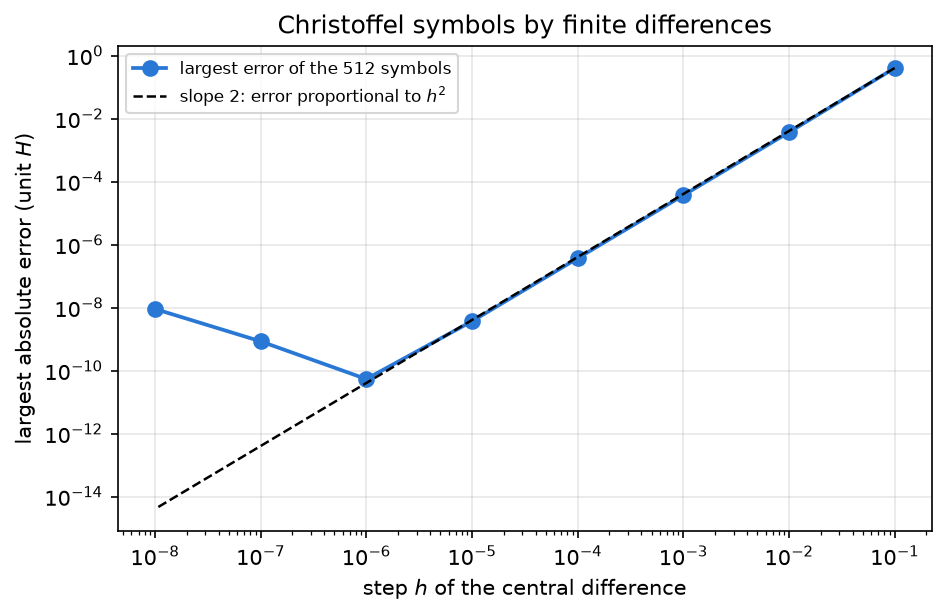

Figure 03b.3 saved as Revision/textbook/figures/03b_3_finite_differences.png
PASS the error shrinks as the step shrinks from 0.1 to 0.0001


In [10]:
fig, ax = plt.subplots()
ax.loglog(steps, errors, "o-", color=BLUE, lw=1.8, ms=7,
          label="largest error of the 512 symbols")
ax.loglog(steps, errors[0] * (steps / steps[0]) ** 2, "--", color="black", lw=1.2,
          label="slope 2: error proportional to $h^2$")
ax.set_xlabel("step $h$ of the central difference")
ax.set_ylabel("largest absolute error (unit $H$)")
ax.set_title("Christoffel symbols by finite differences")
ax.legend(fontsize=8)
best = int(np.argmin(errors))  # the position of the smallest error in the list
report("best step and its error", f"h = {steps[best]:.0e}, error {errors[best]:.1e}")
mantissa, exponent = f"{errors[best]:.1e}".split("e")  # e.g. "3.2" and "-10"
best_error = f"{mantissa} \\times 10^{{{int(exponent)}}}"  # 3.2 x 10^-10 in LaTeX
best_step = f"10^{{{round(np.log10(steps[best]))}}}"  # the step as a power of 10
save_figure(fig, "finite_differences",
            "The largest difference between the 512 Christoffel symbols computed "
            "numerically by central differences of the metric and the exact "
            "symbols, at the test point $H = 0.23$, $a_4 = 0.17$, "
            "$a_4^{\\prime} = 0.61$, $a_4^{\\prime\\prime} = -0.37$, $x_8 = 0.41$ of "
            "the Revision record, against the step $h$, on logarithmic axes; "
            "horizontal axis $h$, vertical axis the error in units of $H$. For "
            "large steps the error follows the dashed line of slope 2 (error "
            "proportional to $h^2$); the smallest error, "
            f"${best_error}$, is reached at $h = {best_step}$; for "
            "smaller steps the rounding errors of the computer, which grow like "
            "$1/h$, take over.")
check(errors[0] > errors[1] > errors[2] > errors[3],
      "the error shrinks as the step shrinks from 0.1 to 0.0001")

## 8. Free fall along the time $x_4$

Consider an observer who stays at fixed $x_1, x_2, x_3, x_5, x_6, x_7, x_8$ while
$x_4 = \tau$ runs. Then $dx^a/d\tau$ is $1$ for $a = x_4$ and $0$ otherwise, and
$d^2x^a/d\tau^2 = 0$, so the geodesic equation reduces to
$\Gamma^a{}_{x_4 x_4} = 0$ for every $a$. Since $g_{44} = -1$, the proper time of
the observer is $\sqrt{-g_{44}}\, d\tau = d\tau$: $x_4$ is the time shown by the
observer's clock. The next cell checks that the eight symbols $\Gamma^a{}_{x_4x_4}$
are zero. It also checks the useful identity $\sum_a \Gamma^a{}_{ab} =
\partial_b \ln\sqrt{|\det g|}$, with $\sqrt{|\det g|} = \cos z$.

In [11]:
check(all(Gamma[a][3][3] == 0 for a in range(8)),
      "Gamma^a_(x4 x4) = 0: observers at rest fall freely, x4 is their proper time")
contracted = [vanishes(sum(Gamma[a][a][b] for a in range(8))
                       - sp.diff(sp.log(sp.cos(6 * H * x8)), X[b]))
              for b in range(8)]
check(all(contracted),
      "sum over a of Gamma^a_(a b) equals the derivative of ln cos z")

PASS Gamma^a_(x4 x4) = 0: observers at rest fall freely, x4 is their proper time
PASS sum over a of Gamma^a_(a b) equals the derivative of ln cos z


## 9. The Riemann tensor

The Riemann tensor in the convention of all Revision records (MTW) is

$$R^a{}_{bcd} = \partial_c \Gamma^a{}_{bd} - \partial_d \Gamma^a{}_{bc}
+ \sum_e \bigl(\Gamma^a{}_{ce}\Gamma^e{}_{bd} - \Gamma^a{}_{de}\Gamma^e{}_{bc}\bigr).$$

It is antisymmetric in its last two indices $c, d$ (exchanging $c$ and $d$ turns the
formula into its negative: the first two terms exchange places and signs, and so do
the two products), so the next cell computes it for $c < d$ and fills $c > d$ with
the opposite sign; the components with $c = d$ are zero. It keeps only the
non-zero components in a dictionary. Then it raises the second index,
$R^{ab}{}_{cd} = \sum_e g^{be} R^a{}_{ecd}$, the form in which the record stores
the tensor. This cell takes a few seconds.

In [12]:
def riemann(table, coordinates):
    """The non-zero R^a_bcd (MTW) as a dictionary {(a, b, c, d): value}."""
    n = len(coordinates)
    result = {}
    for a, b in itertools.product(range(n), repeat=2):
        for c, d in itertools.combinations(range(n), 2):  # all pairs c < d
            value = (sp.diff(table[a][b][d], coordinates[c])
                     - sp.diff(table[a][b][c], coordinates[d])
                     + sum(table[a][c][e] * table[e][b][d]
                           - table[a][d][e] * table[e][b][c] for e in range(n)))
            value = tidy(value)
            if value != 0:
                result[(a, b, c, d)] = value
                result[(a, b, d, c)] = -value  # antisymmetric in c and d
    return result


def raise_second(riemann_table, metric):
    """R^ab_cd = sum over e of g^(be) R^a_ecd, the non-zero ones."""
    inverse = metric.inv()
    result = {}
    for (a, e, c, d), value in riemann_table.items():
        for b in range(metric.rows):
            if inverse[b, e] != 0:
                result[(a, b, c, d)] = result.get((a, b, c, d), 0) \
                    + inverse[b, e] * value
    result = {k: tidy(v) for k, v in result.items()}
    return {k: v for k, v in result.items() if v != 0}


R_down = riemann(Gamma, X)  # R^a_bcd
R_mixed = raise_second(R_down, g)  # R^ab_cd
report("non-zero components R^a_bcd", len(R_down))
report("non-zero components R^ab_cd", len(R_mixed))
check(len(R_mixed) == 156, "R^ab_cd has 156 non-zero components, as in the record",
      record="Revision/gkd_lovelock/results/lovelock-report.json, check "
             "riemann_antisymmetry (156 nonzero entries)")

RESULT non-zero components R^a_bcd = 156
RESULT non-zero components R^ab_cd = 156
PASS R^ab_cd has 156 non-zero components, as in the record
     reproduces Revision/gkd_lovelock/results/lovelock-report.json, check
    riemann_antisymmetry (156 nonzero entries)


The next cell checks the symmetries that every Riemann tensor has, as a test of the
computation: (1) $R^{ab}{}_{cd} = -R^{ba}{}_{cd} = -R^{ab}{}_{dc}$; (2) with all
indices lowered, $R_{abcd} = g_{aa} g_{bb} R^{ab}{}_{cd}$ (diagonal metric), the
pair symmetry $R_{abcd} = R_{cdab}$; (3) the first Bianchi identity
$R^a{}_{bcd} + R^a{}_{cdb} + R^a{}_{dbc} = 0$ for all $8^4 = 4096$ index lists.
It also checks that no component $R^{ab}{}_{cd}$ contains the warp factor
$\sin^{1/3} z$ or the exponential $e^{a_4}$: they cancel when one index is raised.

In [13]:
def get(table, key):
    return table.get(key, 0)


antisymmetric = all(vanishes(v + get(R_mixed, (b, a, c, d)))
                    and vanishes(v + get(R_mixed, (a, b, d, c)))
                    for (a, b, c, d), v in R_mixed.items())
lowered = {(a, b, c, d): g[a, a] * g[b, b] * v
           for (a, b, c, d), v in R_mixed.items()}
pair_symmetric = all(vanishes(v - get(lowered, (c, d, a, b)))
                     for (a, b, c, d), v in lowered.items())
check(antisymmetric and pair_symmetric,
      "R^ab_cd is antisymmetric in a, b and in c, d; R_abcd = R_cdab",
      record="Revision/gkd_lovelock/results/python-lovelock-report.json, check "
             "riemann_antisymmetry_and_pair_symmetry")
bianchi = [vanishes(get(R_down, (a, b, c, d)) + get(R_down, (a, c, d, b))
                    + get(R_down, (a, d, b, c)))
           for a, b, c, d in itertools.product(range(8), repeat=4)]
check(all(bianchi) and len(bianchi) == 4096,
      "the first Bianchi identity holds for all 4096 index lists",
      record="Revision/gkd_lovelock/results/lovelock-report.json, check "
             "riemann_first_bianchi")
warp_free = all(not symbolic(v).has(a4v) and not any(
    isinstance(p, sp.Pow) and p.base == sp.sin(6 * H * x8) and not p.exp.is_integer
    for p in sp.preorder_traversal(symbolic(v))) for v in R_mixed.values())
check(warp_free, "no R^ab_cd contains sin(z)^(1/3) or e^(a4): the warp cancels",
      record="Revision/gkd_lovelock/results/lovelock-report.json, check "
             "mixed_riemann_free_of_sin_third, and python-lovelock-report.json, "
             "check mixed_riemann_free_of_warp_and_exponential")

PASS R^ab_cd is antisymmetric in a, b and in c, d; R_abcd = R_cdab
     reproduces Revision/gkd_lovelock/results/python-lovelock-report.json, check
    riemann_antisymmetry_and_pair_symmetry
PASS the first Bianchi identity holds for all 4096 index lists
     reproduces Revision/gkd_lovelock/results/lovelock-report.json, check
    riemann_first_bianchi
PASS no R^ab_cd contains sin(z)^(1/3) or e^(a4): the warp cancels
     reproduces Revision/gkd_lovelock/results/lovelock-report.json, check
    mixed_riemann_free_of_sin_third, and python-lovelock-report.json, check
    mixed_riemann_free_of_warp_and_exponential


The next cell compares all 156 components with the list `riemannMixedNonzero` of the
record, in which `up` holds $a, b$ and `down` holds $c, d$ of $R^{ab}{}_{cd}$: first
that the same 156 index lists occur, then that each value agrees exactly. It then
groups the 156 components by their value and prints the 14 different values, how
often each occurs and one example of where.

In [14]:
record_riemann = {}
for entry in record["riemannMixedNonzero"]:
    key = tuple(NAMES.index(n) for n in entry["up"] + entry["down"])
    record_riemann[key] = from_mathematica(entry["value"])
check(sorted(record_riemann) == sorted(R_mixed),
      "the same 156 non-zero components R^ab_cd as the record")
check(all(same(R_mixed[k], v) for k, v in record_riemann.items()),
      "every component R^ab_cd equals the record exactly",
      record=f"{CURVATURE_RECORD}, riemannMixedNonzero (and "
             "python-lovelock-report.json, check rust_riemann_agrees)")
groups = {}
for key in sorted(R_mixed):
    groups.setdefault(sp.sstr(plain(R_mixed[key])), []).append(key)
for value_text in sorted(groups):
    a, b, c, d = groups[value_text][0]
    say(f"  {len(groups[value_text]):2d} x  {value_text:30s}  e.g. "
        f"R^({NAMES[a]} {NAMES[b]})_({NAMES[c]} {NAMES[d]})")
report("different values among the 156 components", len(groups))

PASS the same 156 non-zero components R^ab_cd as the record
PASS every component R^ab_cd equals the record exactly
     reproduces Revision/gkd_lovelock/results/curvature.json, riemannMixedNonzero (and
    python-lovelock-report.json, check rust_riemann_agrees)
  12 x  -H**2                           e.g. R^(x1 x8)_(x1 x8)
  12 x  -H**2 + a4p**2                  e.g. R^(x1 x2)_(x1 x2)
  18 x  -H**2 - a4p**2                  e.g. R^(x1 x5)_(x1 x5)
  12 x  -H*a4p*tan(z)                   e.g. R^(x1 x8)_(x1 x4)
  12 x  -H*a4p/tan(z)                   e.g. R^(x1 x4)_(x8 x1)
   6 x  -a4p**2 + a4pp                  e.g. R^(x4 x5)_(x5 x4)
   6 x  -a4p**2 - a4pp                  e.g. R^(x1 x4)_(x4 x1)
  12 x  H**2                            e.g. R^(x1 x8)_(x8 x1)
  18 x  H**2 + a4p**2                   e.g. R^(x1 x5)_(x5 x1)
  12 x  H**2 - a4p**2                   e.g. R^(x1 x2)_(x2 x1)
  12 x  H*a4p*tan(z)                    e.g. R^(x1 x8)_(x4 x1)
  12 x  H*a4p/tan(z)                    e.g. 

## 10. The curvature of every coordinate plane

For two different coordinates $x_a$ and $x_b$ the number $R^{ab}{}_{ab}$ (no sum) is
the curvature of the coordinate plane spanned by them. The next cell computes all
28 of them as formulas, prints one plane of each kind, and checks the six
formulas: 3-space with 3-space and extra time with extra time $a_4'^2 - H^2$;
3-space with an extra time $-(a_4'^2 + H^2)$; 3-space with the time $x_4$
$a_4'^2 + a_4''$; the time with an extra time $a_4'^2 - a_4''$; a 3-space or
extra-time direction with the hidden $x_8$ $-H^2$; the time with the hidden $x_8$
zero. None depends on $z$ or on the value of $a_4$. Then it draws them as
$8 \times 8$ heat maps along the deflating history $a_4 = AHx_4$ ($a_4' = AH$,
$a_4'' = 0$, $H = 1$) for the three slopes $A = 0.5$, $1$ (the canonical value of
the Revision record) and $2$, all positive, so that in all three the extra times
deflate; the diagonal is left empty. The planes inside 3-space and inside the extra
times change sign at $A = 1$: $a_4'^2 - H^2 = H^2(A^2 - 1)$ is negative for $A < 1$,
zero at $A = 1$ and positive for $A > 1$.

  plane (x1, x2): R^ab_ab = -H**2 + a4p**2
  plane (x5, x6): R^ab_ab = -H**2 + a4p**2
  plane (x1, x5): R^ab_ab = -H**2 - a4p**2
  plane (x1, x4): R^ab_ab = a4p**2 + a4pp
  plane (x4, x5): R^ab_ab = a4p**2 - a4pp
  plane (x1, x8): R^ab_ab = -H**2
  plane (x5, x8): R^ab_ab = -H**2
  plane (x4, x8): R^ab_ab = 0
PASS the plane curvatures have the six formulas and do not depend on z or a4


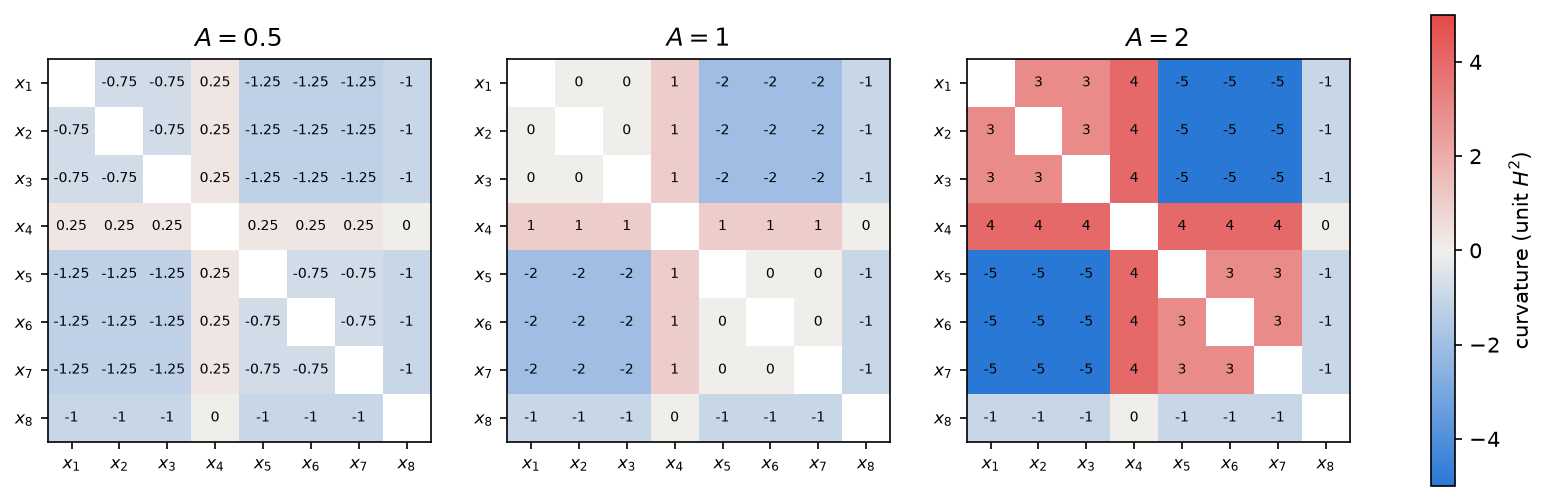

Figure 03b.4 saved as Revision/textbook/figures/03b_4_plane_curvatures.png
PASS the planes inside 3-space: -0.75, 0 and 3 for A = 0.5, 1 and 2


In [15]:
plane = {(a, b): plain(sp.S(get(R_mixed, (a, b, a, b))))  # sp.S: 0 as a sympy 0
         for a, b in itertools.product(range(8), repeat=2) if a != b}
expected = {(0, 1): a4p ** 2 - H ** 2, (4, 5): a4p ** 2 - H ** 2,
            (0, 4): -(a4p ** 2 + H ** 2), (0, 3): a4p ** 2 + a4pp,
            (3, 4): a4p ** 2 - a4pp, (0, 7): -H ** 2, (4, 7): -H ** 2, (3, 7): 0}
for (a, b), formula in expected.items():
    say(f"  plane ({NAMES[a]}, {NAMES[b]}): R^ab_ab = {plane[(a, b)]}")
check(all(sp.expand(plane[key] - formula) == 0 for key, formula in expected.items())
      and all(not v.has(z) and not v.has(a4v) for v in plane.values()),
      "the plane curvatures have the six formulas and do not depend on z or a4")
SLOPES = (0.5, 1.0, 2.0)  # three deflating histories, A > 0
fig, axes = plt.subplots(1, 3, figsize=(14.0, 4.8))  # wide: room for -1.25
for ax, slope in zip(axes, SLOPES):
    curv = np.full((8, 8), np.nan)  # NaN: an empty square on the diagonal
    for (a, b), value in plane.items():
        curv[a, b] = float(value.subs({a4p: slope, a4pp: 0, H: 1}))
    image = ax.imshow(curv, cmap=DIVERGING, vmin=-5.0, vmax=5.0)
    for a, b in plane:
        ax.text(b, a, f"{curv[a, b]:g}", ha="center", va="center", fontsize=6.5)
    ax.set_xticks(range(8), LABELS, fontsize=8)
    ax.set_yticks(range(8), LABELS, fontsize=8)
    ax.grid(False)
    ax.set_title(f"$A = {slope:g}$")
fig.colorbar(image, ax=axes, shrink=0.85, label="curvature (unit $H^2$)")
save_figure(fig, "plane_curvatures",
            "The curvature $R^{ab}{}_{ab}$ (no sum) of the coordinate plane of "
            "$x_a$ (row) and $x_b$ (column), in units of $H^2$, along the deflating "
            "history $a_4 = AHx_4$ ($a_4^{\\prime} = AH$, "
            "$a_4^{\\prime\\prime} = 0$, $H = 1$) for $A = 0.5$ (left), $A = 1$ "
            "(middle, the canonical history of the Revision record) and $A = 2$ "
            "(right); red positive (curved like a sphere), blue negative (curved "
            "like a saddle), grey zero, diagonal empty. The planes inside 3-space "
            "and inside the extra times have $a_4^{\\prime 2} - H^2$ ($-0.75$, $0$, "
            "$3$: the sign changes at $A = 1$); a 3-space direction with an extra "
            "time $-(a_4^{\\prime 2} + H^2)$ ($-1.25$, $-2$, $-5$); the planes with "
            "the time $x_4$ $a_4^{\\prime 2} \\pm a_4^{\\prime\\prime}$ ($0.25$, "
            "$1$, $4$), except the plane of $x_4$ and $x_8$, which is flat; every "
            "other plane with the hidden $x_8$ has $-H^2 = -1$ for every $A$.")
check([float(plane[(0, 1)].subs({a4p: s, H: 1})) for s in SLOPES] == [-0.75, 0.0, 3.0],
      "the planes inside 3-space: -0.75, 0 and 3 for A = 0.5, 1 and 2")

## 11. Ricci tensor, Ricci scalar, Einstein tensor

The next cell contracts the Riemann tensor: $R^a{}_b = \sum_c R^{ac}{}_{bc}$, then
$R = \sum_a R^a{}_a$ and $G^a{}_b = R^a{}_b - \tfrac12 \delta^a{}_b R$. It prints the
diagonal and compares all 64 components of each tensor and the scalar with the
record (`ricciMixed`, `ricciScalar`, `einsteinMixed`).

In [16]:
def ricci(mixed_table, n):
    """R^a_b = sum over c of R^ac_bc, as an n x n sympy matrix."""
    result = sp.zeros(n, n)
    for (a, c, b, d), value in mixed_table.items():
        if c == d:
            result[a, b] += value
    return result.applyfunc(tidy)


Ric = ricci(R_mixed, 8)
R_scalar = tidy(Ric.trace())
G = (Ric - R_scalar / 2 * sp.eye(8)).applyfunc(tidy)
for k in range(8):
    say(f"  {NAMES[k]}: R^a_a = {sp.sstr(plain(Ric[k, k])):18s} "
        f"G^a_a = {plain(G[k, k])}")
say(f"Ricci scalar R = {plain(R_scalar)}")
ricci_ok = all(same(Ric[i, j], from_mathematica(
    record["ricciMixed"][f"{NAMES[i]},{NAMES[j]}"]["mathematica"]))
    for i in range(8) for j in range(8))
einstein_ok = all(same(G[i, j], from_mathematica(
    record["einsteinMixed"][f"{NAMES[i]},{NAMES[j]}"]["mathematica"]))
    for i in range(8) for j in range(8))
scalar_ok = same(R_scalar, from_mathematica(record["ricciScalar"]))
check(ricci_ok and einstein_ok and scalar_ok,
      "all 64 Ricci, all 64 Einstein components and R equal the record",
      record=f"{CURVATURE_RECORD}, ricciMixed, einsteinMixed, ricciScalar (and "
             "python-lovelock-report.json, check rust_ricci_einstein_scalar_agree)")

  x1: R^a_a = -6*H**2 + a4pp     G^a_a = 15*H**2 - 3*a4p**2 + a4pp
  x2: R^a_a = -6*H**2 + a4pp     G^a_a = 15*H**2 - 3*a4p**2 + a4pp
  x3: R^a_a = -6*H**2 + a4pp     G^a_a = 15*H**2 - 3*a4p**2 + a4pp
  x4: R^a_a = 6*a4p**2           G^a_a = 21*H**2 + 3*a4p**2
  x5: R^a_a = -6*H**2 - a4pp     G^a_a = 15*H**2 - 3*a4p**2 - a4pp
  x6: R^a_a = -6*H**2 - a4pp     G^a_a = 15*H**2 - 3*a4p**2 - a4pp
  x7: R^a_a = -6*H**2 - a4pp     G^a_a = 15*H**2 - 3*a4p**2 - a4pp
  x8: R^a_a = -6*H**2            G^a_a = 15*H**2 - 3*a4p**2
Ricci scalar R = -42*H**2 + 6*a4p**2
PASS all 64 Ricci, all 64 Einstein components and R equal the record
     reproduces Revision/gkd_lovelock/results/curvature.json, ricciMixed, einsteinMixed,
    ricciScalar (and python-lovelock-report.json, check rust_ricci_einstein_scalar_agree)


The Ricci scalar appears in one more Revision record, in a different form. The
record of the field equations of $a_4$ builds them from three **Lovelock
scalars** $L_{(1)}, L_{(2)}, L_{(3)}$ (the subject of a later chapter), and the
first of them is exactly twice the Ricci scalar, $L_{(1)} = 2R$ (this identity is
the check `L1_equals_2R` of the record
`Revision/gkd_lovelock/results/python-lovelock-report.json`). The sympy
verification of the record of the field equations,
`Revision/field_equations_a4/reports/python-a4-report.json`, prints $L_{(1)}$ in its
check `L1_equals_gkd_branch`, with the name `ad1` for $a_4'$. The next cell reads
this text, checks that the record marks the check as passed, turns the text after
the equals sign into a sympy expression, and checks $L_{(1)} = 2R$ with our $R$.

In [17]:
A4_REPORT = "Revision/field_equations_a4/reports/python-a4-report.json"
a4_report = json.loads(repository_file(A4_REPORT).read_text(encoding="utf-8"))
# the report's checks form a list of dictionaries; take the one with this name
L1_entry = next(entry for entry in a4_report["checks"]
                if entry["name"] == "L1_equals_gkd_branch")
L1_detail, L1_verdict = L1_entry["detail"], L1_entry["verdict"]
say(f"record: {L1_detail} ({L1_verdict})")
L1_text = L1_detail.split("=")[1]  # the text after the equals sign
L1_record = parse_expr(L1_text, local_dict={"H": H, "ad1": a4p})
check(L1_verdict == "PASS" and sp.expand(L1_record - 2 * plain(R_scalar)) == 0,
      "the first Lovelock scalar of the record is twice our Ricci scalar",
      record=f"{A4_REPORT}, check L1_equals_gkd_branch (with "
             "python-lovelock-report.json, check L1_equals_2R)")

record: L_(1) = -84*H**2 + 12*ad1**2 (PASS)
PASS the first Lovelock scalar of the record is twice our Ricci scalar
     reproduces Revision/field_equations_a4/reports/python-a4-report.json, check
    L1_equals_gkd_branch (with python-lovelock-report.json, check L1_equals_2R)


Exact agreement was decided by sympy's simplification. A second, independent test
uses numbers only: the independent Revision verification
(`Revision/gkd_lovelock/results/python-lovelock-report.json`, list `randomPoints`)
chose five test points, each a set of exact fractions for $H$, $x_8$, $a_4$, $a_4'$
and $a_4''$. The next cell evaluates every component of the record (25 Christoffel
symbols, 156 Riemann components, 64 Ricci and 64 Einstein components and the Ricci
scalar) and our component with the same indices at these five points, with
**30 significant digits** (the package mpmath; `sp.lambdify(..., "mpmath")` turns an
expression into an mpmath function), and reports the largest relative difference
$|{\rm ours} - {\rm record}| / \max(1, |{\rm record}|)$.

In [18]:
PYTHON_REPORT = "Revision/gkd_lovelock/results/python-lovelock-report.json"
python_report = json.loads(repository_file(PYTHON_REPORT).read_text(encoding="utf-8"))
mpmath.mp.dps = 30  # mpmath works with 30 significant digits from now on


def exact(text):
    """A fraction such as 46/75 of the record as an mpmath number."""
    fraction = sp.Rational(text)
    return mpmath.mpf(fraction.p) / fraction.q  # numerator / denominator


test_points = [[exact(p["H"]), exact(p["x8"]), exact(p["a4"]),
                exact(p["a4" + prime]), exact(p["a4" + prime + prime])]
               for p in python_report["randomPoints"]]
pairs = [(Gamma[a][b][c], v) for (a, b, c), v in record_gamma.items()]
pairs += [(R_mixed[key], v) for key, v in record_riemann.items()]
pairs += [(Ric[i, j], from_mathematica(record["ricciMixed"][f"{NAMES[i]},{NAMES[j]}"]
                                       ["mathematica"]))
          for i in range(8) for j in range(8)]
pairs += [(G[i, j], from_mathematica(record["einsteinMixed"][f"{NAMES[i]},{NAMES[j]}"]
                                     ["mathematica"]))
          for i in range(8) for j in range(8)]
pairs += [(R_scalar, from_mathematica(record["ricciScalar"]))]
ARGS30 = (H, x8, a4v, a4p, a4pp)  # the order of the five numbers of a test point
largest, evaluations = mpmath.mpf(0), 0
for mine, theirs in pairs:
    f_mine = sp.lambdify(ARGS30, symbolic(sp.S(mine)), "mpmath")
    f_record = sp.lambdify(ARGS30, sp.S(theirs), "mpmath")
    for point in test_points:
        ours, recorded = f_mine(*point), f_record(*point)
        largest = max(largest, abs(ours - recorded) / max(1, abs(recorded)))
        evaluations += 1
report("components compared numerically", len(pairs))
report("evaluations at the five test points", evaluations)
report("largest relative difference (30 digits)", mpmath.nstr(largest, 3))
check(len(test_points) == 5 and largest < mpmath.mpf(10) ** -25,
      "at the five test points every component agrees to more than 25 digits",
      record="Revision/gkd_lovelock/results/python-lovelock-report.json, "
             "randomPoints, checks rust_christoffels_agree, rust_riemann_agrees, "
             "rust_ricci_einstein_scalar_agree")

RESULT components compared numerically = 310
RESULT evaluations at the five test points = 1550
RESULT largest relative difference (30 digits) = 1.48e-31
PASS at the five test points every component agrees to more than 25 digits
     reproduces Revision/gkd_lovelock/results/python-lovelock-report.json, randomPoints,
    checks rust_christoffels_agree, rust_riemann_agrees, rust_ricci_einstein_scalar_agree


The lead's independent check of the field equations
(`Revision/lead_checks/reports/einstein-gauss-bonnet-a4.json`) states four
properties of the Einstein tensor; the next cell checks them on our result: $G$ is
diagonal (in particular $G^{x_4}{}_{x_8} = 0$), no component depends on $x_8$, the
three 3-space components are equal and the three extra-time components are equal,
and $G^{x_4}{}_{x_4} - G^{x_8}{}_{x_8} = 6(a_4'^2 + H^2)$, which is positive for
$H > 0$ (a later chapter uses this to show that for $H > 0$ no empty spacetime, not
even one with a cosmological constant, has this metric: some matter is needed).

In [19]:
LEAD = "Revision/lead_checks/reports/einstein-gauss-bonnet-a4.json"
check(all(G[i, j] == 0 for i in range(8) for j in range(8) if i != j),
      "the Einstein tensor is diagonal",
      record=f"{LEAD}, check einstein_off_diagonal_zero")
check(all(sp.diff(G[i, i], x8) == 0 for i in range(8)),
      "no component of the Einstein tensor depends on x8",
      record=f"{LEAD}, check einstein_x8_independent")
check(G[0, 0] == G[1, 1] == G[2, 2] and G[4, 4] == G[5, 5] == G[6, 6],
      "3-space components equal, extra-time components equal",
      record=f"{LEAD}, check einstein_isotropy")
gap = sp.simplify(symbolic(G[3, 3] - G[7, 7]))
say(f"G^x4_x4 - G^x8_x8 = {sp.factor(gap)}")
check(sp.simplify(gap - 6 * (a4p ** 2 + H ** 2)) == 0,
      "G^x4_x4 - G^x8_x8 = 6 (a4p^2 + H^2) > 0",
      record=f"{LEAD}, check no_vacuum_for_H_positive")

PASS the Einstein tensor is diagonal
     reproduces Revision/lead_checks/reports/einstein-gauss-bonnet-a4.json, check
    einstein_off_diagonal_zero
PASS no component of the Einstein tensor depends on x8
     reproduces Revision/lead_checks/reports/einstein-gauss-bonnet-a4.json, check
    einstein_x8_independent
PASS 3-space components equal, extra-time components equal
     reproduces Revision/lead_checks/reports/einstein-gauss-bonnet-a4.json, check
    einstein_isotropy
G^x4_x4 - G^x8_x8 = 6*(H**2 + a4p**2)
PASS G^x4_x4 - G^x8_x8 = 6 (a4p^2 + H^2) > 0
     reproduces Revision/lead_checks/reports/einstein-gauss-bonnet-a4.json, check
    no_vacuum_for_H_positive


Every Einstein tensor satisfies the **contracted Bianchi identity**
$\nabla_\mu G^\mu{}_\nu = 0$, where for a tensor with one upper and one lower index
$\nabla_\mu G^\mu{}_\nu = \sum_\mu \partial_\mu G^\mu{}_\nu + \sum_{\mu,\lambda}
\Gamma^\mu{}_{\mu\lambda} G^\lambda{}_\nu - \sum_{\mu,\lambda} \Gamma^\lambda{}_{\mu\nu}
G^\mu{}_\lambda$. It is the reason why the energy of the matter that sources the
metric must be conserved. The next cell computes the eight components with the
function $a_4(x_4)$ (so that sympy can differentiate $a_4''$ and produce $a_4'''$)
and checks that each simplifies to zero. The Rust program checked the same for its
tensor $P_{(1)} = -4G$.

In [20]:
divergence = []
for nu in range(8):
    value = sum(sp.diff(G[mu, nu], X[mu]) for mu in range(8)) \
        + sum(Gamma[mu][mu][lam] * G[lam, nu] for mu in range(8) for lam in range(8)) \
        - sum(Gamma[lam][mu][nu] * G[mu, lam] for mu in range(8) for lam in range(8))
    divergence.append(vanishes(value))
check(all(divergence),
      "the contracted Bianchi identity: the divergence of G vanishes",
      record="Revision/gkd_lovelock/results/lovelock-report.json, checks "
             "k1_equals_minus_4_einstein and k1_divergence_free")

PASS the contracted Bianchi identity: the divergence of G vanishes
     reproduces Revision/gkd_lovelock/results/lovelock-report.json, checks
    k1_equals_minus_4_einstein and k1_divergence_free


## 12. The Kretschmann scalar: an invariant that does not see $z$

The next cell computes $K = \sum R^{ab}{}_{cd} R^{cd}{}_{ab}$ and
$\sum_{a,b} R^a{}_b R^b{}_a$ from our components, and computes $K$ a second time
from the 156 components of the record alone. Although some components depend on
$z$ (for example $R^{x_1x_4}{}_{x_1x_8} = H a_4' \cot z$), their products combine so
that $K$ depends only on $H$, $a_4'$ and $a_4''$. Completing the square,

$$\frac{K}{12} = 7H^4 - 2H^2 a_4'^2 + 7 a_4'^4 + 2 a_4''^2
= 7\Bigl(a_4'^2 - \frac{H^2}{7}\Bigr)^2 + \frac{48}{7} H^4 + 2 a_4''^2 ,$$

(expand the square: $7 a_4'^4 - 2 H^2 a_4'^2 + H^4/7$, and $H^4/7 + 48 H^4/7 =
7 H^4$), so $K \ge \frac{576}{7} H^4 > 0$ for every history: the metric is curved
for every $H > 0$. The cell checks all of this.

In [21]:
K = sp.factor(sp.expand(symbolic(sum(v * get(R_mixed, (c, d, a, b))
                                     for (a, b, c, d), v in R_mixed.items()))))
K_record = sp.factor(sp.expand(sum(v * record_riemann.get((c, d, a, b), 0)
                                   for (a, b, c, d), v in record_riemann.items())))
ricci_square = sp.factor(sp.expand(symbolic(sum(Ric[i, j] * Ric[j, i]
                                                for i in range(8)
                                                for j in range(8)))))
say(f"Kretschmann scalar K = {K}")
say(f"sum of R^a_b R^b_a  = {ricci_square}")
check(sp.simplify(K - K_record) == 0,
      "K from our components equals K from the 156 components of the record")
check(not K.has(x8) and not K.has(a4v),
      "K depends only on H, a4p and a4pp, not on z and not on a4")
square_form = 7 * (a4p ** 2 - H ** 2 / 7) ** 2 + sp.Rational(48, 7) * H ** 4 \
    + 2 * a4pp ** 2
check(sp.expand(K / 12 - square_form) == 0,
      "K/12 = 7 (a4p^2 - H^2/7)^2 + 48 H^4/7 + 2 a4pp^2, so K > 0 for H > 0")
report("smallest possible K (at a4p^2 = H^2/7, a4pp = 0)",
       sp.sstr(sp.Rational(576, 7) * H ** 4))

Kretschmann scalar K = 12*(7*H**4 - 2*H**2*a4p**2 + 7*a4p**4 + 2*a4pp**2)
sum of R^a_b R^b_a  = 6*(42*H**4 + 6*a4p**4 + a4pp**2)
PASS K from our components equals K from the 156 components of the record
PASS K depends only on H, a4p and a4pp, not on z and not on a4
PASS K/12 = 7 (a4p^2 - H^2/7)^2 + 48 H^4/7 + 2 a4pp^2, so K > 0 for H > 0
RESULT smallest possible K (at a4p^2 = H^2/7, a4pp = 0) = 576*H**4/7


The next cell shows the cancellation in pictures, for $a_4'' = 0$ and $H = 1$. Left:
the sizes of two $z$-dependent components, $R^{x_1x_4}{}_{x_1x_8} = H a_4' \cot z$
and $R^{x_1x_8}{}_{x_1x_4} = -H a_4' \tan z$, of their product $-H^2 a_4'^2$ and of
the constant component $R^{x_1x_8}{}_{x_1x_8} = -H^2$, for $a_4' = 1.5$ (so that the
product, $2.25$, and $H^2 = 1$ are different numbers). Right: $K$
computed at 300 values of $z$ by summing all 156 products numerically, for four
expansion rates $a_4' = A H$ of deflating histories, $A = 0.5, 1, 1.5, 2$: four
flat lines.

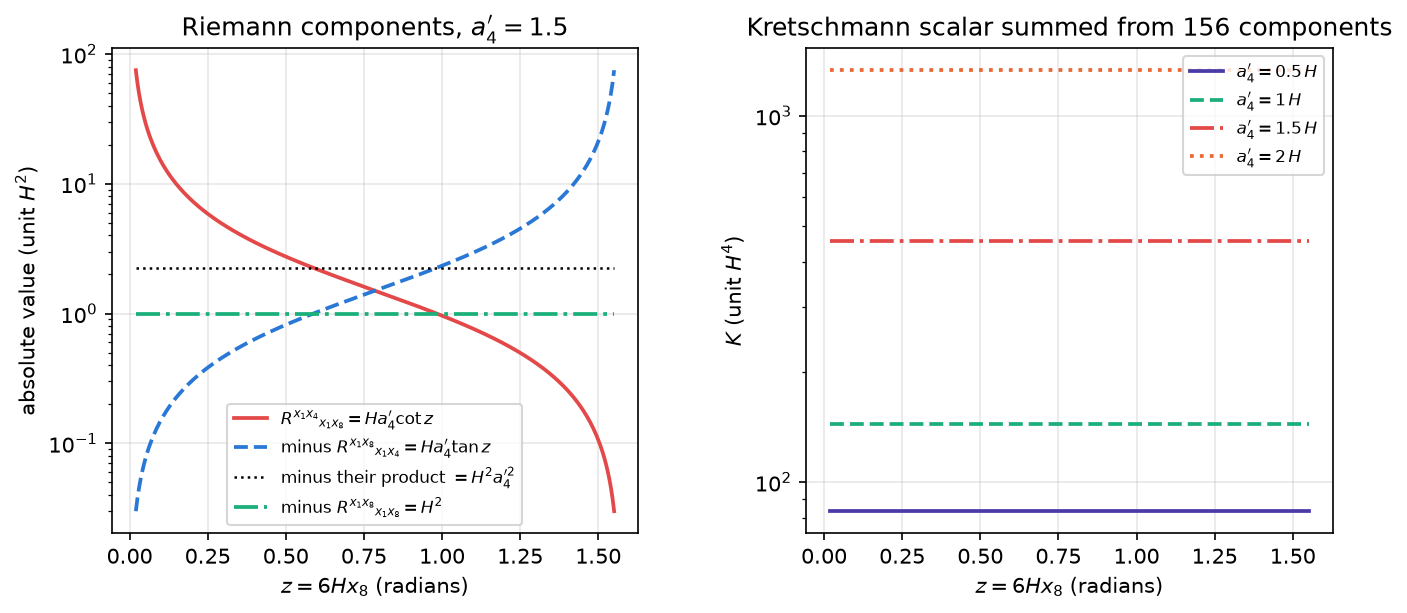

Figure 03b.5 saved as Revision/textbook/figures/03b_5_riemann_and_kretschmann_z.png
PASS summed numerically, K is the same at all 300 values of z and equals the formula


In [22]:
# numerical functions of the 156 components with a4pp = 0 (true on the history
# a4 = A H x4); the second derivative of a4 is replaced by 0 before lambdify
riemann_functions = {k: numeric(v.subs(sp.Derivative(a4, (x4, 2)), 0))
                     for k, v in R_mixed.items()}


def kretschmann_numbers(z_values, rate):
    """K at the points z_values, summed from the 156 numerical components."""
    total = np.zeros_like(z_values)
    for (a, b, c, d), f in riemann_functions.items():
        partner = riemann_functions.get((c, d, a, b))
        if partner is not None:
            total += f(z_values, 0.5, rate, 1.0) * partner(z_values, 0.5, rate, 1.0)
    return total


z_line = np.linspace(0.02, np.pi / 2 - 0.02, 300)
cot_part = riemann_functions[(0, 3, 0, 7)](z_line, 0.5, 1.5, 1.0)  # a4p = 1.5
tan_part = riemann_functions[(0, 7, 0, 3)](z_line, 0.5, 1.5, 1.0)
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))
fig.subplots_adjust(wspace=0.32)  # room for the label of the right vertical axis
axes[0].plot(z_line, np.abs(cot_part), color=RED, lw=1.8,
             label="$R^{x_1x_4}{}_{x_1x_8} = Ha_4^{\\prime}\\cot z$")
axes[0].plot(z_line, np.abs(tan_part), color=BLUE, lw=1.8, ls="--",
             label="minus $R^{x_1x_8}{}_{x_1x_4} = Ha_4^{\\prime}\\tan z$")
axes[0].plot(z_line, np.abs(cot_part * tan_part), color="black", lw=1.2, ls=":",
             label="minus their product $= H^2 a_4^{\\prime 2}$")
axes[0].plot(z_line, np.abs(np.broadcast_to(
    riemann_functions[(0, 7, 0, 7)](z_line, 0.5, 1.5, 1.0), z_line.shape)),
    color=AQUA, lw=1.8, ls="-.", label="minus $R^{x_1x_8}{}_{x_1x_8} = H^2$")
axes[0].set_yscale("log")
axes[0].set_xlabel("$z = 6 H x_8$ (radians)")
axes[0].set_ylabel("absolute value (unit $H^2$)")
axes[0].set_title("Riemann components, $a_4^{\\prime} = 1.5$")
axes[0].legend(fontsize=8)
rates = (0.5, 1.0, 1.5, 2.0)  # four expansion rates a4p = A H (A > 0), unit H
for rate, colour, style in zip(rates, (VIOLET, AQUA, RED, ORANGE),
                               ("-", "--", "-.", ":")):
    axes[1].plot(z_line, kretschmann_numbers(z_line, rate), color=colour, ls=style,
                 lw=1.8, label=f"$a_4^{{\\prime}} = {rate:g}\\,H$")
axes[1].set_yscale("log")
axes[1].set_xlabel("$z = 6 H x_8$ (radians)")
axes[1].set_ylabel("$K$ (unit $H^4$)")
axes[1].set_title("Kretschmann scalar summed from 156 components")
axes[1].legend(fontsize=8)
# the values of the formula for K at the four rates, for the caption and the check
K_values = [float(K.subs({a4p: r, a4pp: 0, H: 1})) for r in rates]
K_text = ", ".join(f"${k:g}$" for k in K_values)
save_figure(fig, "riemann_and_kretschmann_z",
            "Left: the absolute values of the Riemann components "
            "$R^{x_1x_4}{}_{x_1x_8} = Ha_4^{\\prime}\\cot z$ (solid) and "
            "$R^{x_1x_8}{}_{x_1x_4} = -Ha_4^{\\prime}\\tan z$ (dashed), of their "
            "product (dotted) and of $R^{x_1x_8}{}_{x_1x_8} = -H^2$ (dash-dotted) "
            "across the patch, for $a_4^{\\prime} = 1.5$, "
            "$a_4^{\\prime\\prime} = 0$, $H = 1$; horizontal axis $z = 6Hx_8$ in "
            "radians, vertical axis on a logarithmic scale in units of $H^2$. "
            "Right: the Kretschmann scalar $K$ summed numerically from all 156 "
            "components at 300 values of $z$ for $a_4^{\\prime} = 0.5, 1, 1.5, 2$ "
            "(in units of $H$), vertical axis $K$ in units of $H^4$, logarithmic. "
            "Single components grow without bound at the ends of the patch, but $K$ "
            f"is the same at every $z$: {K_text}.")
numbers = [kretschmann_numbers(z_line, r) for r in rates]
check(all(np.max(np.abs(n - k)) < 1e-9 * k for n, k in zip(numbers, K_values)),
      "summed numerically, K is the same at all 300 values of z and equals the "
      "formula")

## 13. The curvature along the deflating history

Along the history $a_4 = A H x_4$ we have $a_4' = A H$ and $a_4'' = 0$, so every
curvature scalar is a polynomial in the slope $A$. The author's extra times deflate
when $a_4$ increases, that is for $A > 0$; the Revision record uses $A = 1$. The
next cell evaluates the Ricci scalar $R = 6H^2(A^2 - 7)$, the sum
$\sum R^a{}_b R^b{}_a$ and $K$ as formulas in $A$, checks that they are **even** in
$A$ (they do not change when $A$ is replaced by $-A$; so these three scalars cannot
tell which of the two families of directions deflates, the metric and the
components of the curvature tensors can), and draws them for $0 \le A \le 3$ (the
extra times deflate for every $A > 0$): $R$ on an ordinary axis (it vanishes at
$A = \sqrt 7$), the two squares on a logarithmic axis.

on the history: R = 6*H**2*(A**2 - 7),  K = 12*H**4*(7*A**4 - 2*A**2 + 7),  R^a_b R^b_a =
    36*H**4*(A**4 + 7)
PASS the curvature scalars are even in A


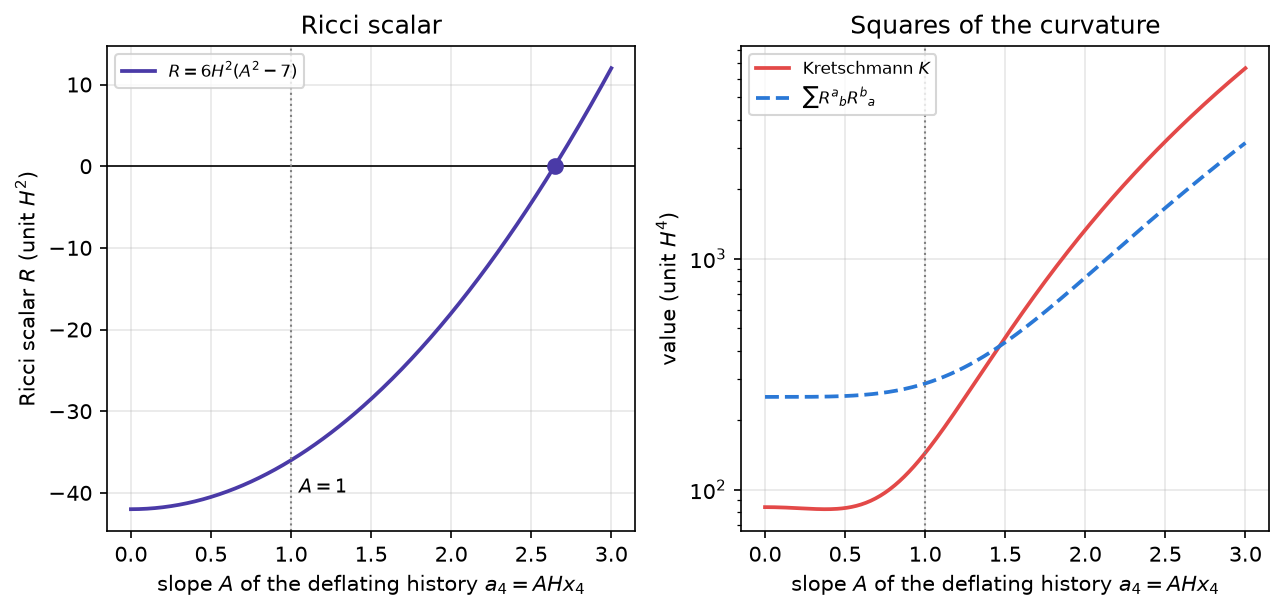

Figure 03b.6 saved as Revision/textbook/figures/03b_6_scalars_versus_a.png
PASS at A = 1: R = -36 H^2 and K = 144 H^4


In [23]:
A = sp.symbols("A", real=True)  # the slope of the history a4 = A H x4
on_history = {a4p: A * H, a4pp: 0}
R_A = sp.factor(symbolic(R_scalar).subs(on_history))
K_A = sp.factor(K.subs(on_history))
RR_A = sp.factor(ricci_square.subs(on_history))
say(f"on the history: R = {R_A},  K = {K_A},  R^a_b R^b_a = {RR_A}")
check(all(sp.expand(f.subs(A, -A) - f) == 0 for f in (R_A, K_A, RR_A)),
      "the curvature scalars are even in A")
A_line = np.linspace(0.0, 3.0, 301)  # slopes 0, 0.01, ..., 3; A_line[100] = 1
R_numbers = sp.lambdify(A, R_A.subs(H, 1))(A_line)
K_numbers = sp.lambdify(A, K_A.subs(H, 1))(A_line)
RR_numbers = sp.lambdify(A, RR_A.subs(H, 1))(A_line)
fig, axes = plt.subplots(1, 2, figsize=(10.0, 4.2))
axes[0].plot(A_line, R_numbers, color=VIOLET, lw=1.8, label="$R = 6H^2(A^2 - 7)$")
axes[0].axhline(0.0, color="black", lw=0.8)
axes[0].plot([np.sqrt(7)], [0.0], "o", color=VIOLET, ms=7)  # the zero of R
axes[0].set_ylabel("Ricci scalar $R$ (unit $H^2$)")
axes[0].set_title("Ricci scalar")
axes[1].plot(A_line, K_numbers, color=RED, lw=1.8, label="Kretschmann $K$")
axes[1].plot(A_line, RR_numbers, color=BLUE, lw=1.8, ls="--",
             label="$\\sum R^a{}_b R^b{}_a$")
axes[1].set_yscale("log")
axes[1].set_ylabel("value (unit $H^4$)")
axes[1].set_title("Squares of the curvature")
for ax in axes:
    ax.axvline(1.0, color="grey", lw=1.0, ls=":")  # the canonical slope A = 1
    ax.set_xlabel("slope $A$ of the deflating history $a_4 = A H x_4$")
    ax.legend(fontsize=8, loc="upper left")
axes[0].text(1.05, -40, "$A = 1$", fontsize=9)
save_figure(fig, "scalars_versus_a",
            "The curvature scalars of the author's metric along the deflating "
            "history $a_4 = AHx_4$ ($a_4^{\\prime} = AH$, "
            "$a_4^{\\prime\\prime} = 0$) as functions of the slope $A$ from $0$ "
            "to $3$, with $H = 1$; horizontal axes $A$ (a pure number), the dotted "
            "vertical line marks the canonical $A = 1$ of the Revision record. "
            "Left: the Ricci scalar $R = 6H^2(A^2 - 7)$ in units of $H^2$, "
            "negative for $A < \\sqrt 7$ and zero at the dot. Right, on a "
            "logarithmic axis in units of $H^4$: the Kretschmann scalar "
            "$K = 12H^4(7A^4 - 2A^2 + 7)$ (solid), smallest at "
            "$A^2 = 1/7$, and $\\sum R^a{}_b R^b{}_a = 36H^4(A^4 + 7)$ (dashed), "
            "both positive for every $A$.")
check(abs(R_numbers[100] - (-36.0)) < 1e-9 and abs(K_numbers[100] - 144.0) < 1e-9,
      "at A = 1: R = -36 H^2 and K = 144 H^4")

The next cell draws the Einstein tensor along the deflating history. Left: its
eight diagonal components as bars, for the canonical slope $A = 1$ of the Revision
record and for $A = 2$. Right: as functions of $A$; with $a_4'' = 0$ the 3-space,
extra-time and hidden components coincide,
$G^{x_1}{}_{x_1} = G^{x_5}{}_{x_5} = G^{x_8}{}_{x_8} = 3H^2(5 - A^2)$, and
$G^{x_4}{}_{x_4} = 3H^2(7 + A^2)$; the gap between them, $6H^2(A^2 + 1)$, is never
zero.

  on the history: G^x1_x1 = -3*H**2*(A**2 - 5)
  on the history: G^x4_x4 = 3*H**2*(A**2 + 7)
  on the history: G^x5_x5 = -3*H**2*(A**2 - 5)
  on the history: G^x8_x8 = -3*H**2*(A**2 - 5)


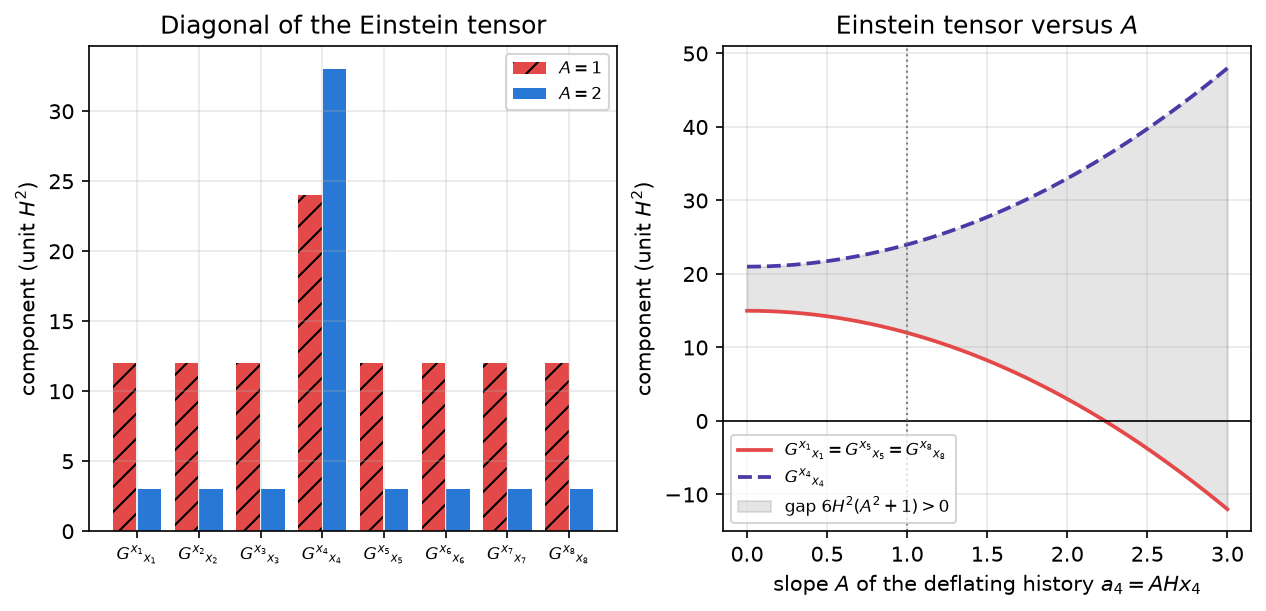

Figure 03b.7 saved as Revision/textbook/figures/03b_7_einstein_tensor.png
PASS diagonal of G: 12 (24 for x4) at A = 1 and 3 (33 for x4) at A = 2, unit H^2


In [24]:
G_A = [sp.factor(symbolic(G[k, k]).subs(on_history)) for k in range(8)]
for k in (0, 3, 4, 7):
    say(f"  on the history: G^{NAMES[k]}_{NAMES[k]} = {G_A[k]}")
bars = {value: [float(G_A[k].subs({A: value, H: 1})) for k in range(8)]
        for value in (1, 2)}
fig, axes = plt.subplots(1, 2, figsize=(10.0, 4.2))
positions = np.arange(8)
axes[0].bar(positions - 0.2, bars[1], width=0.38, color=RED, hatch="//",
            label="$A = 1$")
axes[0].bar(positions + 0.2, bars[2], width=0.38, color=BLUE, label="$A = 2$")
axes[0].set_xticks(positions, [f"$G^{{x_{k}}}{{}}_{{x_{k}}}$" for k in range(1, 9)],
                   fontsize=8)
axes[0].set_ylabel("component (unit $H^2$)")
axes[0].set_title("Diagonal of the Einstein tensor")
axes[0].legend(fontsize=8)
space_numbers = sp.lambdify(A, G_A[0].subs(H, 1))(A_line)
time_numbers = sp.lambdify(A, G_A[3].subs(H, 1))(A_line)
axes[1].plot(A_line, space_numbers, color=RED, lw=1.8,
             label="$G^{x_1}{}_{x_1} = G^{x_5}{}_{x_5} = G^{x_8}{}_{x_8}$")
axes[1].plot(A_line, time_numbers, color=VIOLET, lw=1.8, ls="--",
             label="$G^{x_4}{}_{x_4}$")
axes[1].fill_between(A_line, space_numbers, time_numbers, color="grey", alpha=0.2,
                     label="gap $6H^2(A^2 + 1) > 0$")
axes[1].axhline(0.0, color="black", lw=0.8)
axes[1].axvline(1.0, color="grey", lw=1.0, ls=":")  # the canonical slope A = 1
axes[1].set_xlabel("slope $A$ of the deflating history $a_4 = A H x_4$")
axes[1].set_ylabel("component (unit $H^2$)")
axes[1].set_title("Einstein tensor versus $A$")
axes[1].legend(fontsize=8, loc="lower left")
save_figure(fig, "einstein_tensor",
            "The Einstein tensor $G^{\\mu}{}_{\\nu}$ of the author's metric along "
            "the deflating history $a_4 = AHx_4$ with $H = 1$, in units of $H^2$. "
            "Left: the eight diagonal components (the only non-zero ones) for the "
            "canonical slope $A = 1$ of the Revision record (hatched bars: "
            "$12, 12, 12, 24, 12, 12, 12, 12$) and for $A = 2$ (plain bars: "
            "$3, 3, 3, 33, 3, 3, 3, 3$). Right: the 3-space, extra-time and hidden "
            "components $3H^2(5 - A^2)$ (solid) and the time component "
            "$3H^2(7 + A^2)$ (dashed) as functions of the slope $A$ from $0$ to "
            "$3$; the shaded gap $6H^2(A^2 + 1)$ between them never closes.")
check(bars[1] == [12.0, 12.0, 12.0, 24.0, 12.0, 12.0, 12.0, 12.0]
      and bars[2] == [3.0, 3.0, 3.0, 33.0, 3.0, 3.0, 3.0, 3.0],
      "diagonal of G: 12 (24 for x4) at A = 1 and 3 (33 for x4) at A = 2, unit H^2")

What do these numbers mean for matter? Einstein's field equations (section 3 of
this notebook) set $G^\mu{}_\nu + \Lambda\,\delta^\mu{}_\nu = \kappa\, T^\mu{}_\nu$
with $T = \mathrm{diag}(p_3, p_3, p_3, -\rho, p_t, p_t, p_t, p_8)$. Their $x_4$
component reads $G^{x_4}{}_{x_4} + \Lambda = -\kappa\rho$, so
$\kappa\rho = -G^{x_4}{}_{x_4} - \Lambda$; their $x_1$, $x_5$ and $x_8$ components
read $G^{x_1}{}_{x_1} + \Lambda = \kappa p_3$, $G^{x_5}{}_{x_5} + \Lambda = \kappa
p_t$ and $G^{x_8}{}_{x_8} + \Lambda = \kappa p_8$. Along the history the three
components on the left are equal (previous cell), so all three pressures must be
the same number $p$. The Revision record of the field equations of $a_4$
(`Revision/field_equations_a4/a4-equations.json`, entry `linearMember`) lists this
required source in its texts `rhoEinstein` ($\rho$), `pEinstein` ($p$) and
`rhoPlusPEinstein` ($\rho + p$), written with `AA` for $A$ and `Lam` for $\Lambda$.
The next cell reads the three texts, turns them into sympy expressions and checks
them against our Einstein tensor. The sum $\kappa(\rho + p) = -6(A^2 + 1)H^2$ is
negative for every $A$. Ordinary matter (dust, radiation, a gas) has
$\rho + p \ge 0$ (the **null energy condition**), so within Einstein's equations
the source that this history requires is not ordinary matter; a later chapter
discusses this, also for the field equations with the additional Lovelock terms.
Here we only check that the record and our curvature agree.

In [25]:
A4_EQUATIONS = "Revision/field_equations_a4/a4-equations.json"
a4_equations = json.loads(repository_file(A4_EQUATIONS).read_text(encoding="utf-8"))
linear = a4_equations["linearMember"]  # the entry of the linear history
kappa = sp.symbols("kappa", positive=True)  # the constant of Einstein's equations
Lam = sp.symbols("Lam", real=True)  # the cosmological constant Lambda
source_names = {"AA": A, "H": H, "kappa": kappa, "Lam": Lam}


def source(key):
    """The record's text linear[key] (Mathematica notation) as sympy."""
    return parse_expr(linear[key]["input"].replace("^", "**"),
                      local_dict=source_names)


rho_record, p_record = source("rhoEinstein"), source("pEinstein")
sum_record = source("rhoPlusPEinstein")  # rho + p
say(f"record: kappa rho       = {sp.expand(kappa * rho_record)}")
say(f"record: kappa p         = {sp.expand(kappa * p_record)}")
say(f"record: kappa (rho + p) = {sp.factor(kappa * sum_record)}")
check(sp.expand(kappa * rho_record - (-G_A[3] - Lam)) == 0,
      "kappa rho of the record equals -G^x4_x4 - Lambda",
      record=f"{A4_EQUATIONS}, linearMember.rhoEinstein (and "
             "python-a4-report.json, check json_linear_member)")
check(all(sp.expand(kappa * p_record - (G_A[k] + Lam)) == 0 for k in (0, 4, 7)),
      "kappa p of the record equals G^x1_x1, G^x5_x5 and G^x8_x8 plus Lambda",
      record=f"{A4_EQUATIONS}, linearMember.pEinstein")
check(sp.expand(kappa * sum_record - (G_A[0] - G_A[3])) == 0,
      "kappa (rho + p) of the record equals G^x1_x1 - G^x4_x4 = -6 (A^2 + 1) H^2",
      record=f"{A4_EQUATIONS}, linearMember.rhoPlusPEinstein")

record: kappa rho       = -3*A**2*H**2 - 21*H**2 - Lam
record: kappa p         = -3*A**2*H**2 + 15*H**2 + Lam
record: kappa (rho + p) = -6*H**2*(A**2 + 1)
PASS kappa rho of the record equals -G^x4_x4 - Lambda
     reproduces Revision/field_equations_a4/a4-equations.json, linearMember.rhoEinstein
    (and python-a4-report.json, check json_linear_member)
PASS kappa p of the record equals G^x1_x1, G^x5_x5 and G^x8_x8 plus Lambda
     reproduces Revision/field_equations_a4/a4-equations.json, linearMember.pEinstein
PASS kappa (rho + p) of the record equals G^x1_x1 - G^x4_x4 = -6 (A^2 + 1) H^2
     reproduces Revision/field_equations_a4/a4-equations.json,
    linearMember.rhoPlusPEinstein


## 14. A negative control: what if the extra times inflated?

A check that cannot fail teaches nothing. So the next cell changes the metric on
purpose: the extra times now **inflate** like 3-space, $g_{55} = g_{66} = g_{77} =
-e^{+2a_4}\sin^{1/3} z$ (this is NOT the author's metric), and computes the
curvature again with the same functions. In the author's metric the
$x_4$-$x_8$ components cancelled between the three inflating and the three deflating
directions; here they add up. The cell prints the off-diagonal Einstein components
that appear and checks that they are not zero and that they depend on $z$.

In [26]:
g_control = g.copy()
for k in (4, 5, 6):  # the three extra times, now inflating
    g_control[k, k] = -sp.exp(2 * a4) * sp.sin(6 * H * x8) ** sp.Rational(1, 3)
Gamma_control = christoffel(g_control, X)
R_control = raise_second(riemann(Gamma_control, X), g_control)
Ric_control = ricci(R_control, 8)
G_control = (Ric_control - Ric_control.trace() / 2 * sp.eye(8)).applyfunc(tidy)
off = {(i, j): plain(G_control[i, j]) for i in range(8) for j in range(8)
       if i != j and G_control[i, j] != 0}
for (i, j), value in sorted(off.items()):
    say(f"  control: G^{NAMES[i]}_{NAMES[j]} = {value}")
check(sorted(off) == [(3, 7), (7, 3)] and all(v.has(z) for v in off.values()),
      "negative control: with inflating extra times G^x4_x8 and G^x8_x4 are not "
      "zero and depend on z")

  control: G^x4_x8 = 6*H*a4p/tan(z)
  control: G^x8_x4 = -6*H*a4p*tan(z)
PASS negative control: with inflating extra times G^x4_x8 and G^x8_x4 are not zero and
    depend on z


## 15. The last check

The last cell checks that the seven figure files exist in the folder
Revision/textbook/figures and prints the number of checks that passed.

In [27]:
figure_names = ["christoffel_heat_maps", "christoffel_versus_z",
                "finite_differences", "plane_curvatures",
                "riemann_and_kretschmann_z", "scalars_versus_a", "einstein_tensor"]
files = [output_file(f"{FIGURE_FOLDER}/03b_{k}_{n}.png")
         for k, n in enumerate(figure_names, 1)]
check(all(path.is_file() for path in files), "all seven figure files exist")
all_checks_passed()

PASS all seven figure files exist
ALL 39 CHECKS PASSED (notebook 03b)


## 16. What this notebook showed

- From the metric exactly as the author typed it, sympy computed 37 non-zero
  Christoffel symbols (25 with $b \le c$), 156 non-zero Riemann components
  $R^{ab}{}_{cd}$ with 14 different values, the Ricci tensor, the Ricci scalar
  $R = 6a_4'^2 - 42H^2$ and the Einstein tensor; every component agrees exactly
  with the Revision record of the Rust program `lovelock_gkd` (PROVED by exact
  algebra, here and in the record); at the five test points of the independent
  Revision verification all 310 recorded components agree with ours to more than 25
  significant digits. Twice our Ricci scalar equals the first Lovelock scalar
  $L_{(1)}$ of the record of the field equations of $a_4$.
- The Christoffel symbols were confirmed a second way, by finite differences, with
  an error that falls like $h^2$.
- The lines along $x_4$ are geodesics: observers at rest fall freely and $x_4$ is
  their proper time.
- The Riemann tensor has all the symmetries of a Riemann tensor and satisfies the
  first Bianchi identity; the Einstein tensor satisfies the contracted Bianchi
  identity, is diagonal, isotropic in 3-space and in the extra times, and does not
  depend on $x_8$; $G^{x_4}{}_{x_4} - G^{x_8}{}_{x_8} = 6(a_4'^2 + H^2) > 0$.
- The Kretschmann scalar $K = 12(7H^4 - 2H^2a_4'^2 + 7a_4'^4 + 2a_4''^2)$ does not
  depend on $z$ although single components do, and $K \ge 576H^4/7 > 0$: the metric
  is curved for every $H > 0$.
- Along the deflating history $a_4 = AHx_4$ the curvature scalars are
  $R = 6H^2(A^2 - 7)$, $K = 12H^4(7A^4 - 2A^2 + 7)$ and
  $\sum R^a{}_b R^b{}_a = 36H^4(A^4 + 7)$, all even in $A$. For the canonical
  history of the Revision record ($A = 1$, $H = 1$): $R = -36$, $K = 144$ and
  $G = \mathrm{diag}(12, 12, 12, 24, 12, 12, 12, 12)$ (units $H^2$ and $H^4$); for
  $A = 2$: $G = \mathrm{diag}(3, 3, 3, 33, 3, 3, 3, 3)$.
- Through Einstein's equations this Einstein tensor is exactly the source that the
  Revision record of the field equations of $a_4$ lists for the linear history:
  $\kappa\rho = -3(7 + A^2)H^2 - \Lambda$, $\kappa p = 3(5 - A^2)H^2 + \Lambda$ for
  all three pressures, and $\kappa(\rho + p) = -6(A^2 + 1)H^2 < 0$.
- Negative control: if the extra times inflated instead of deflating, the Einstein
  tensor would acquire the off-diagonal components $G^{x_4}{}_{x_8}$ and
  $G^{x_8}{}_{x_4}$: comparing the two metrics, it is the deflation of the extra
  times that makes the Einstein tensor of the author's metric diagonal.
- ASSUMED for the plots and the evaluation along the history only: the history
  $a_4 = AHx_4$ with $A > 0$ (a prescribed background, not solved for); every
  formula with a general $a_4(x_4)$ is exact.